In [1]:
import torch
# Centralized Quality Metrics Function with Artifact Avoidance
def calculate_quality_metrics(original, reconstructed, crop_pixels=5):
    """
    Calculate PSNR and SSIM between two tensors, avoiding edge artifacts by cropping border pixels.
    
    Args:
        original: Original tensor (can be single image or batch)
        reconstructed: Reconstructed tensor (same shape as original)
        crop_pixels: Number of pixels to crop from each side (default: 5)
    
    Returns:
        dict: Dictionary containing 'psnr' and 'ssim' values
    """
    # Ensure tensors are float and on CPU for consistency
    orig = original.float().cpu()
    recon = reconstructed.float().cpu()
    
    # Handle different tensor dimensions
    if orig.dim() == 2:  # Single 2D image
        orig = orig.unsqueeze(0)  # Add batch dimension
        recon = recon.unsqueeze(0)
    elif orig.dim() == 4:  # Video tensor (N, C, H, W)
        orig = orig.squeeze(1) if orig.shape[1] == 1 else orig.mean(dim=1)  # Remove channel or average RGB
        recon = recon.squeeze(1) if recon.shape[1] == 1 else recon.mean(dim=1)
    
    # Crop edge pixels to avoid compression artifacts
    if orig.shape[-1] > 2 * crop_pixels and orig.shape[-2] > 2 * crop_pixels:
        orig_cropped = orig[..., crop_pixels:-crop_pixels, crop_pixels:-crop_pixels]
        recon_cropped = recon[..., crop_pixels:-crop_pixels, crop_pixels:-crop_pixels]
    else:
        # If image is too small to crop, use full image but warn
        orig_cropped = orig
        recon_cropped = recon
        print(f"⚠️  Image too small to crop {crop_pixels} pixels, using full image")
    
    # Calculate PSNR
    mse = torch.mean((orig_cropped - recon_cropped) ** 2)
    if mse > 0:
        # Assume normalized input [0, 1] range
        max_val = orig_cropped.max()
        psnr = 20 * torch.log10(max_val / torch.sqrt(mse))
    else:
        psnr = torch.tensor(float('inf'))
    
    # Calculate SSIM
    def ssim_2d(x, y):
        """Calculate SSIM for 2D tensors"""
        mu_x = torch.mean(x)
        mu_y = torch.mean(y)
        
        mu_x_sq = mu_x ** 2
        mu_y_sq = mu_y ** 2
        mu_xy = mu_x * mu_y
        
        sigma_x_sq = torch.var(x)
        sigma_y_sq = torch.var(y)
        sigma_xy = torch.mean((x - mu_x) * (y - mu_y))
        
        # SSIM constants
        c1 = (0.01) ** 2
        c2 = (0.03) ** 2
        
        ssim_val = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / \
                   ((mu_x_sq + mu_y_sq + c1) * (sigma_x_sq + sigma_y_sq + c2))
        
        return ssim_val
    
    # Calculate SSIM (average over batch if multiple frames)
    if orig_cropped.dim() == 3:  # Batch of images
        ssim_values = []
        for i in range(orig_cropped.shape[0]):
            ssim_val = ssim_2d(orig_cropped[i], recon_cropped[i])
            ssim_values.append(ssim_val)
        ssim = torch.mean(torch.stack(ssim_values))
    else:  # Single image
        ssim = ssim_2d(orig_cropped, recon_cropped)
    
    return {
        'psnr': psnr.item() if not torch.isinf(psnr) else float('inf'),
        'ssim': ssim.item(),
        'mse': mse.item(),
        'cropped_shape': orig_cropped.shape,
        'crop_pixels': crop_pixels
    }

print("✅ Quality metrics function loaded")
print("   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5)")
print("   Features: Automatic edge cropping, PSNR & SSIM calculation, batch support")

✅ Quality metrics function loaded
   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5)
   Features: Automatic edge cropping, PSNR & SSIM calculation, batch support


## Import Required Libraries

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from pathlib import Path
import lovely_tensors as lt

# Import video compression utilities
from sdate.video_compression import encode_hevc_grayscale_10bit, decode_hevc_grayscale_10bit

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

import lovely_tensors as lt
lt.monkey_patch()

import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
import torch
import gc
from tqdm.auto import tqdm
import itertools

# Check if chip package is available for plotting utilities
try:
    from chip.utils.plotting import plot_tomogram_overview, plot_sinogram
    CHIP_AVAILABLE = True
except ImportError:
    print("Warning: chip package not available. Some plotting functions may not work.")
    CHIP_AVAILABLE = False

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Libraries imported successfully!
PyTorch version: 2.7.1
Device: CPU


## 2. Load Aligned Projections Data from HDF5

Load the aligned projection data from HDF5 files, similar to the approach used in the Chip Data Exploration notebook.

In [ ]:
# Configure data paths - adapt these paths based on your setup
DATA_PATH = '/mydata/chip/shared/ra.psi.ch/p17299/data_for_SDSC/'

# Fallback path for local development 
if not torch.cuda.is_available() or not os.path.exists(DATA_PATH):
    DATA_PATH = '../../chip-project/data/p17299_v0/'
    DATA_PATH = '/Users/lfbarba/GitHub/chip-project/data/brain'

print(f"Using data path: {DATA_PATH}")

# Check if data path exists
if not os.path.exists(DATA_PATH):
    print(f"Warning: Data path {DATA_PATH} does not exist!")
    print("Please update DATA_PATH to point to your HDF5 data directory.")
    print("Expected files: phase_projections_aligned.mat, tomogram_delta.mat")
else:
    print("Data path exists. Checking for required files...")
    
    aligned_file = os.path.join(DATA_PATH, 'stack_object_external.mat')
    tomogram_file = os.path.join(DATA_PATH, 'tomogram_delta.mat')
    
    print(f"Aligned projections: {'✓' if os.path.exists(aligned_file) else '✗'} {aligned_file}")
    print(f"Tomogram data: {'✓' if os.path.exists(tomogram_file) else '✗'} {tomogram_file}")

Using data path: /Users/lfbarba/GitHub/chip-project/data/brain
Data path exists. Checking for required files...
Aligned projections: ✓ /Users/lfbarba/GitHub/chip-project/data/brain/stack_object_external.mat
Tomogram data: ✗ /Users/lfbarba/GitHub/chip-project/data/brain/tomogram_delta.mat


In [8]:
# Load HDF5 files
try:
    # Load aligned projections data
    h5_projections_aligned = h5py.File(os.path.join(DATA_PATH, 'stack_object_external.mat'), 'r')
    
    # Load tomogram data for reference
    # h5_tomogram = h5py.File(os.path.join(DATA_PATH, 'tomogram_delta.mat'), 'r')
    
    print("Successfully opened HDF5 files!")
    print(f"\nAligned projections datasets: {list(h5_projections_aligned.keys())}")
    # print(f"Tomogram datasets: {list(h5_tomogram.keys())}")
    
    # Extract key data
    angles_numpy = np.array(h5_projections_aligned.get('theta'))

    sinogram_data = h5_projections_aligned.get('stack_object_i')
    
    print(f"\nData shapes:")
    print(f"Angles: {angles_numpy.shape}")
    print(f"Sinogram: {sinogram_data.shape}")
    
    if 'total_shift' in h5_projections_aligned:
        total_shift = h5_projections_aligned.get('total_shift')
        print(f"Total shift: {total_shift.shape}")
    
    HDF5_LOADED = True
    
except FileNotFoundError as e:
    print(f"Error: Could not find HDF5 files: {e}")
    print("This notebook requires the aligned projections data to run.")
    HDF5_LOADED = False
except Exception as e:
    print(f"Error loading HDF5 files: {e}")
    HDF5_LOADED = False

Successfully opened HDF5 files!

Aligned projections datasets: ['#refs#', 'object_ROI', 'par', 'stack_object_i', 'stack_object_r', 'theta', 'total_shift']

Data shapes:
Angles: (780, 1)
Sinogram: (780, 1426, 1025)
Total shift: (2, 780)


# Video Compression Analysis

In [12]:
# Import compression utilities
import torch
import cv2
from tqdm.auto import tqdm
import pandas as pd

if HDF5_LOADED:
    # Use all layers and order them according to the angles
    num_layers = sinogram_data.shape[2]
    num_angles = len(angles_numpy)
    print(f"Total available layers: {num_layers}")
    print(f"Number of angles: {num_angles}")

    # Sort angles and get the permutation
    angles_tensor = torch.tensor(angles_numpy.reshape(-1))
    sorted_angles, sort_indices = angles_tensor.sort()
    print(f"Angle range: [{sorted_angles.min():.2f}, {sorted_angles.max():.2f}] degrees")

    # Create empty tensor with the same shape as sinogram_data
    video_data = torch.zeros(sinogram_data.shape, dtype=torch.float32)

    # Iterate over sinogram_data and place each frame in the correct position based on sorted order
    for i in tqdm(range(len(angles_tensor))):
        # Get the original index from the sorted permutation
        original_idx = sort_indices[i]
        video_data[i] = torch.from_numpy(np.array(sinogram_data[original_idx])).float()

    # print min max and other stats
    print(f"video_data shape: {video_data.shape}")
    print(f"video_data range: [{video_data.min():.3f}, {video_data.max():.3f}]")

    video_data = video_data.clip(-1, 1)
    video_data -= video_data.min()  # Normalize to [0, max]
    video_data /= video_data.max()  # Normalize to [0, 1]
    print("video_data", video_data)
    video_data = video_data.transpose(-1, -2)
    video_normalized = video_data
    
    # Update angles to use sorted version
    angles = sorted_angles.numpy().reshape(-1, 1)
    
else:
    print("⚠️  HDF5 data not loaded. Creating synthetic data for demonstration...")
    
    # Create synthetic video data for testing
    n_frames, height, width = 30, 256, 256
    video_normalized = torch.randn(n_frames, height, width).abs()
    video_normalized = video_normalized / video_normalized.max()
    
    print(f"Synthetic tensor shape: {video_normalized.shape}")
    print(f"Synthetic range: [{video_normalized.min():.3f}, {video_normalized.max():.3f}]")

Total available layers: 1025
Number of angles: 780
Angle range: [-360.11, -0.12] degrees


  0%|          | 0/780 [00:00<?, ?it/s]

video_data shape: torch.Size([780, 1426, 1025])
video_data range: [-2.241, 2.321]
video_data tensor[780, 1426, 1025] n=1140087000 (4.2Gb) x∈[0., 1.000] μ=0.464 σ=0.085


📊 Computing MSE differences between frames and first frame...
Computing MSE for every 1th frame...


Computing MSE: 100%|██████████| 780/780 [00:00<00:00, 940.20it/s] 


✅ Computed MSE for 780 frames


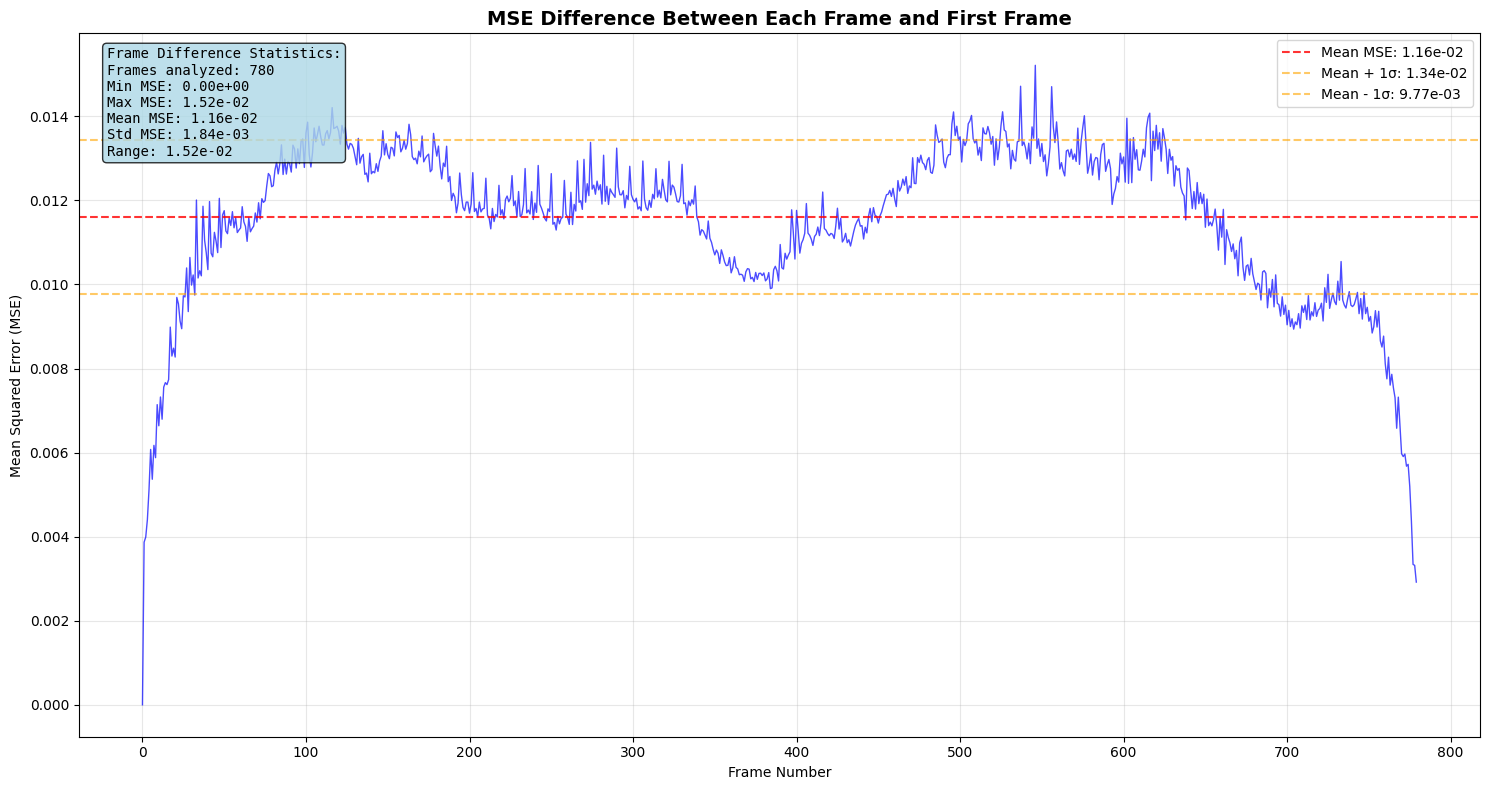


📈 MSE Analysis Summary:
   Minimum MSE: 0.00e+00
   Maximum MSE: 1.52e-02
   Mean MSE: 1.16e-02
   Standard Deviation: 1.84e-03
   Dynamic Range: infx


/var/folders/tz/dk16058s17q23bj28chlys680000gn/T/ipykernel_12922/3582159837.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"   Dynamic Range: {max_mse/min_mse:.1f}x")


In [13]:
from tqdm import tqdm
# Compute MSE differences between each frame and the first frame
print("📊 Computing MSE differences between frames and first frame...")

# Get the first frame as reference
reference_frame = video_normalized[0].float()

# Compute MSE for each frame compared to the first frame
mse_differences = []
frame_indices = []

# Sample frames for computation (every 100th frame for speed, or all if small dataset)
step_size = 1
print(f"Computing MSE for every {step_size}th frame...")

for i in tqdm(range(0, len(video_normalized), step_size), desc="Computing MSE"):
    current_frame = video_normalized[i].float()
    mse = torch.mean((current_frame - reference_frame) ** 2).item()
    mse_differences.append(mse)
    frame_indices.append(i)

print(f"✅ Computed MSE for {len(mse_differences)} frames")

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(frame_indices, mse_differences, 'b-', alpha=0.7, linewidth=1)
plt.title('MSE Difference Between Each Frame and First Frame', fontsize=14, fontweight='bold')
plt.xlabel('Frame Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)

# Add statistics
mean_mse = np.mean(mse_differences)
std_mse = np.std(mse_differences)
max_mse = np.max(mse_differences)
min_mse = np.min(mse_differences)

plt.axhline(y=mean_mse, color='r', linestyle='--', alpha=0.8, label=f'Mean MSE: {mean_mse:.2e}')
plt.axhline(y=mean_mse + std_mse, color='orange', linestyle='--', alpha=0.6, label=f'Mean + 1σ: {mean_mse + std_mse:.2e}')
plt.axhline(y=mean_mse - std_mse, color='orange', linestyle='--', alpha=0.6, label=f'Mean - 1σ: {mean_mse - std_mse:.2e}')

plt.legend()
plt.tight_layout()

# Add text box with statistics
stats_text = f'''Frame Difference Statistics:
Frames analyzed: {len(mse_differences)}
Min MSE: {min_mse:.2e}
Max MSE: {max_mse:.2e}
Mean MSE: {mean_mse:.2e}
Std MSE: {std_mse:.2e}
Range: {max_mse - min_mse:.2e}'''

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.show()

print(f"\n📈 MSE Analysis Summary:")
print(f"   Minimum MSE: {min_mse:.2e}")
print(f"   Maximum MSE: {max_mse:.2e}")
print(f"   Mean MSE: {mean_mse:.2e}")
print(f"   Standard Deviation: {std_mse:.2e}")
print(f"   Dynamic Range: {max_mse/min_mse:.1f}x")

In [19]:
encode_hevc_grayscale_10bit(video_normalized, "chip_sinogram_10b.mov", fps=24, crf_sw=14, preset_sw="veryslow", cq_hw=100) # 90 is visually lossless, crf_sw=14 is visually lossless
reconstructed_video = decode_hevc_grayscale_10bit("chip_sinogram_10b.mov", device="cpu")

print("reconstructed_video", reconstructed_video)

📤  encoding 780 × 1426×1025 frames  (grayscale 10-bit HEVC)
✓ hardware encode succeeded
reconstructed_video tensor[780, 1024, 1426] n=1138974720 (4.2Gb) x∈[1.526e-05, 0.999] μ=0.464 σ=0.085


In [20]:
# Load the compressed video for comparison
print("🎬 Loading Compressed Video for Quality Analysis")
print("=" * 60)

try:
    # Load the compressed video
    compressed_video_path = "chip_sinogram_10b.mov"
    
    # Check if file exists and get size
    if os.path.exists(compressed_video_path):
        compressed_file_size = os.path.getsize(compressed_video_path)
        print(f"📁 Compressed file found: {compressed_video_path}")
        print(f"📏 Compressed file size: {compressed_file_size / 1e6:.2f} MB")
    else:
        raise FileNotFoundError(f"Compressed video file not found: {compressed_video_path}")
    
    # Load the video back into tensor
    # reconstructed_video = load_video_to_tensor(compressed_video_path, target_frames=NUM_FRAMES)
    
    # Calculate original data size
    original_tensor_size = video_normalized.numel() * video_normalized.element_size()
    
    print(f"\n📊 Size Comparison:")
    print(f"   Original tensor size: {original_tensor_size / 1e6:.2f} MB")
    print(f"   Compressed file size: {compressed_file_size / 1e6:.2f} MB")
    
    # Calculate compression ratio
    compression_ratio = original_tensor_size / compressed_file_size
    space_savings = (1 - compressed_file_size / original_tensor_size) * 100
    
    print(f"   Compression ratio: {compression_ratio:.1f}:1")
    print(f"   Space savings: {space_savings:.1f}%")
    
    print(f"\n✅ Video loaded successfully for comparison")
    
except Exception as e:
    print(f"❌ Error loading compressed video: {e}")
    print("   Make sure the video was encoded successfully")
    reconstructed_video = None

🎬 Loading Compressed Video for Quality Analysis
📁 Compressed file found: chip_sinogram_10b.mov
📏 Compressed file size: 677.95 MB

📊 Size Comparison:
   Original tensor size: 4560.35 MB
   Compressed file size: 677.95 MB
   Compression ratio: 6.7:1
   Space savings: 85.1%

✅ Video loaded successfully for comparison


In [21]:
# Calculate Quality Metrics using Centralized Function (with 5-pixel crop)
if reconstructed_video is not None:
    print("📈 Calculating Quality Metrics with Artifact Avoidance")
    print("=" * 60)
    
    # Ensure both tensors have the same dimensions for comparison
    min_frames = min(video_normalized.shape[0], reconstructed_video.shape[0])
    min_height = min(video_normalized.shape[1], reconstructed_video.shape[1])
    min_width = min(video_normalized.shape[2], reconstructed_video.shape[2])

    # Crop both videos to same size
    original_crop = video_normalized[:min_frames, :min_height, :min_width].float()
    reconstructed_crop = reconstructed_video[:min_frames, :min_height, :min_width]
    
    print(f"Comparing tensors with shape: {original_crop.shape}")
    
    # Normalize original to [0, 1] if needed
    if original_crop.max() > 1.0:
        original_normalized = (original_crop - original_crop.min()) / (original_crop.max() - original_crop.min())
    else:
        original_normalized = original_crop
    
    # Use centralized quality metrics function with 5-pixel crop
    print(f"🔍 Using centralized quality metrics with 5-pixel edge crop...")
    metrics = calculate_quality_metrics(original_normalized, reconstructed_crop, crop_pixels=5)
    
    # Extract results
    psnr_value = metrics['psnr']
    ssim_value = metrics['ssim']
    mse = metrics['mse']
    cropped_shape = metrics['cropped_shape']
    
    print(f"🎯 PSNR: {psnr_value:.2f} dB (cropped region: {cropped_shape})")
    print(f"🎯 SSIM: {ssim_value:.6f}")
    print(f"📊 MSE: {mse:.2e}")
    
    # Calculate per-frame statistics using centralized function
    print(f"\n📊 Per-Frame Statistics (5-pixel crop applied):")
    frame_psnrs = []
    frame_ssims = []
    
    for i in range(min(10, min_frames)):  # Sample first 10 frames
        frame_metrics = calculate_quality_metrics(
            original_normalized[i:i+1], 
            reconstructed_crop[i:i+1], 
            crop_pixels=5
        )
        frame_psnrs.append(frame_metrics['psnr'])
        frame_ssims.append(frame_metrics['ssim'])
    
    # Filter out any infinite values for statistics
    finite_psnrs = [p for p in frame_psnrs if p != float('inf')]
    
    if finite_psnrs:
        print(f"   Average PSNR (first 10 frames): {np.mean(finite_psnrs):.2f} dB")
        print(f"   Average SSIM (first 10 frames): {np.mean(frame_ssims):.6f}")
        print(f"   PSNR range: [{min(finite_psnrs):.2f}, {max(finite_psnrs):.2f}] dB")
        print(f"   SSIM range: [{min(frame_ssims):.6f}, {max(frame_ssims):.6f}]")
    else:
        print(f"   Average PSNR (first 10 frames): {np.mean(frame_psnrs):.2f} dB")
        print(f"   Average SSIM (first 10 frames): {np.mean(frame_ssims):.6f}")
    
    # Quality assessment
    print(f"\n🏆 Quality Assessment:")
    if psnr_value > 40:
        quality_rating = "Excellent"
    elif psnr_value > 30:
        quality_rating = "Very Good"
    elif psnr_value > 25:
        quality_rating = "Good"
    elif psnr_value > 20:
        quality_rating = "Fair"
    else:
        quality_rating = "Poor"
    
    print(f"   Overall Quality: {quality_rating}")
    print(f"   SSIM Quality: {'Excellent' if ssim_value > 0.95 else 'Very Good' if ssim_value > 0.9 else 'Good' if ssim_value > 0.8 else 'Fair'}")
    
    # Additional information about cropping
    original_pixels = min_frames * min_height * min_width
    cropped_pixels = cropped_shape[0] * cropped_shape[1] * cropped_shape[2] if len(cropped_shape) == 3 else cropped_shape[0] * cropped_shape[1]
    edge_pixels_removed = original_pixels - cropped_pixels
    
    print(f"\n💡 Artifact Avoidance Info:")
    print(f"   Edge pixels removed: {edge_pixels_removed:,} ({edge_pixels_removed/original_pixels*100:.1f}%)")
    print(f"   Analysis region: {cropped_shape}")
    print(f"   Crop applied: 5 pixels from each edge")
    
else:
    print("⚠️  Cannot calculate quality metrics - compressed video not loaded")

📈 Calculating Quality Metrics with Artifact Avoidance
Comparing tensors with shape: torch.Size([780, 1024, 1426])
🔍 Using centralized quality metrics with 5-pixel edge crop...
🎯 PSNR: 69.67 dB (cropped region: torch.Size([780, 1014, 1416]))
🎯 SSIM: 0.999992
📊 MSE: 1.08e-07

📊 Per-Frame Statistics (5-pixel crop applied):
   Average PSNR (first 10 frames): 69.67 dB
   Average SSIM (first 10 frames): 0.999990
   PSNR range: [69.67, 69.68] dB
   SSIM range: [0.999990, 0.999991]

🏆 Quality Assessment:
   Overall Quality: Excellent
   SSIM Quality: Excellent

💡 Artifact Avoidance Info:
   Edge pixels removed: 19,032,000 (1.7%)
   Analysis region: torch.Size([780, 1014, 1416])
   Crop applied: 5 pixels from each edge


🎨 Creating Visual Comparison


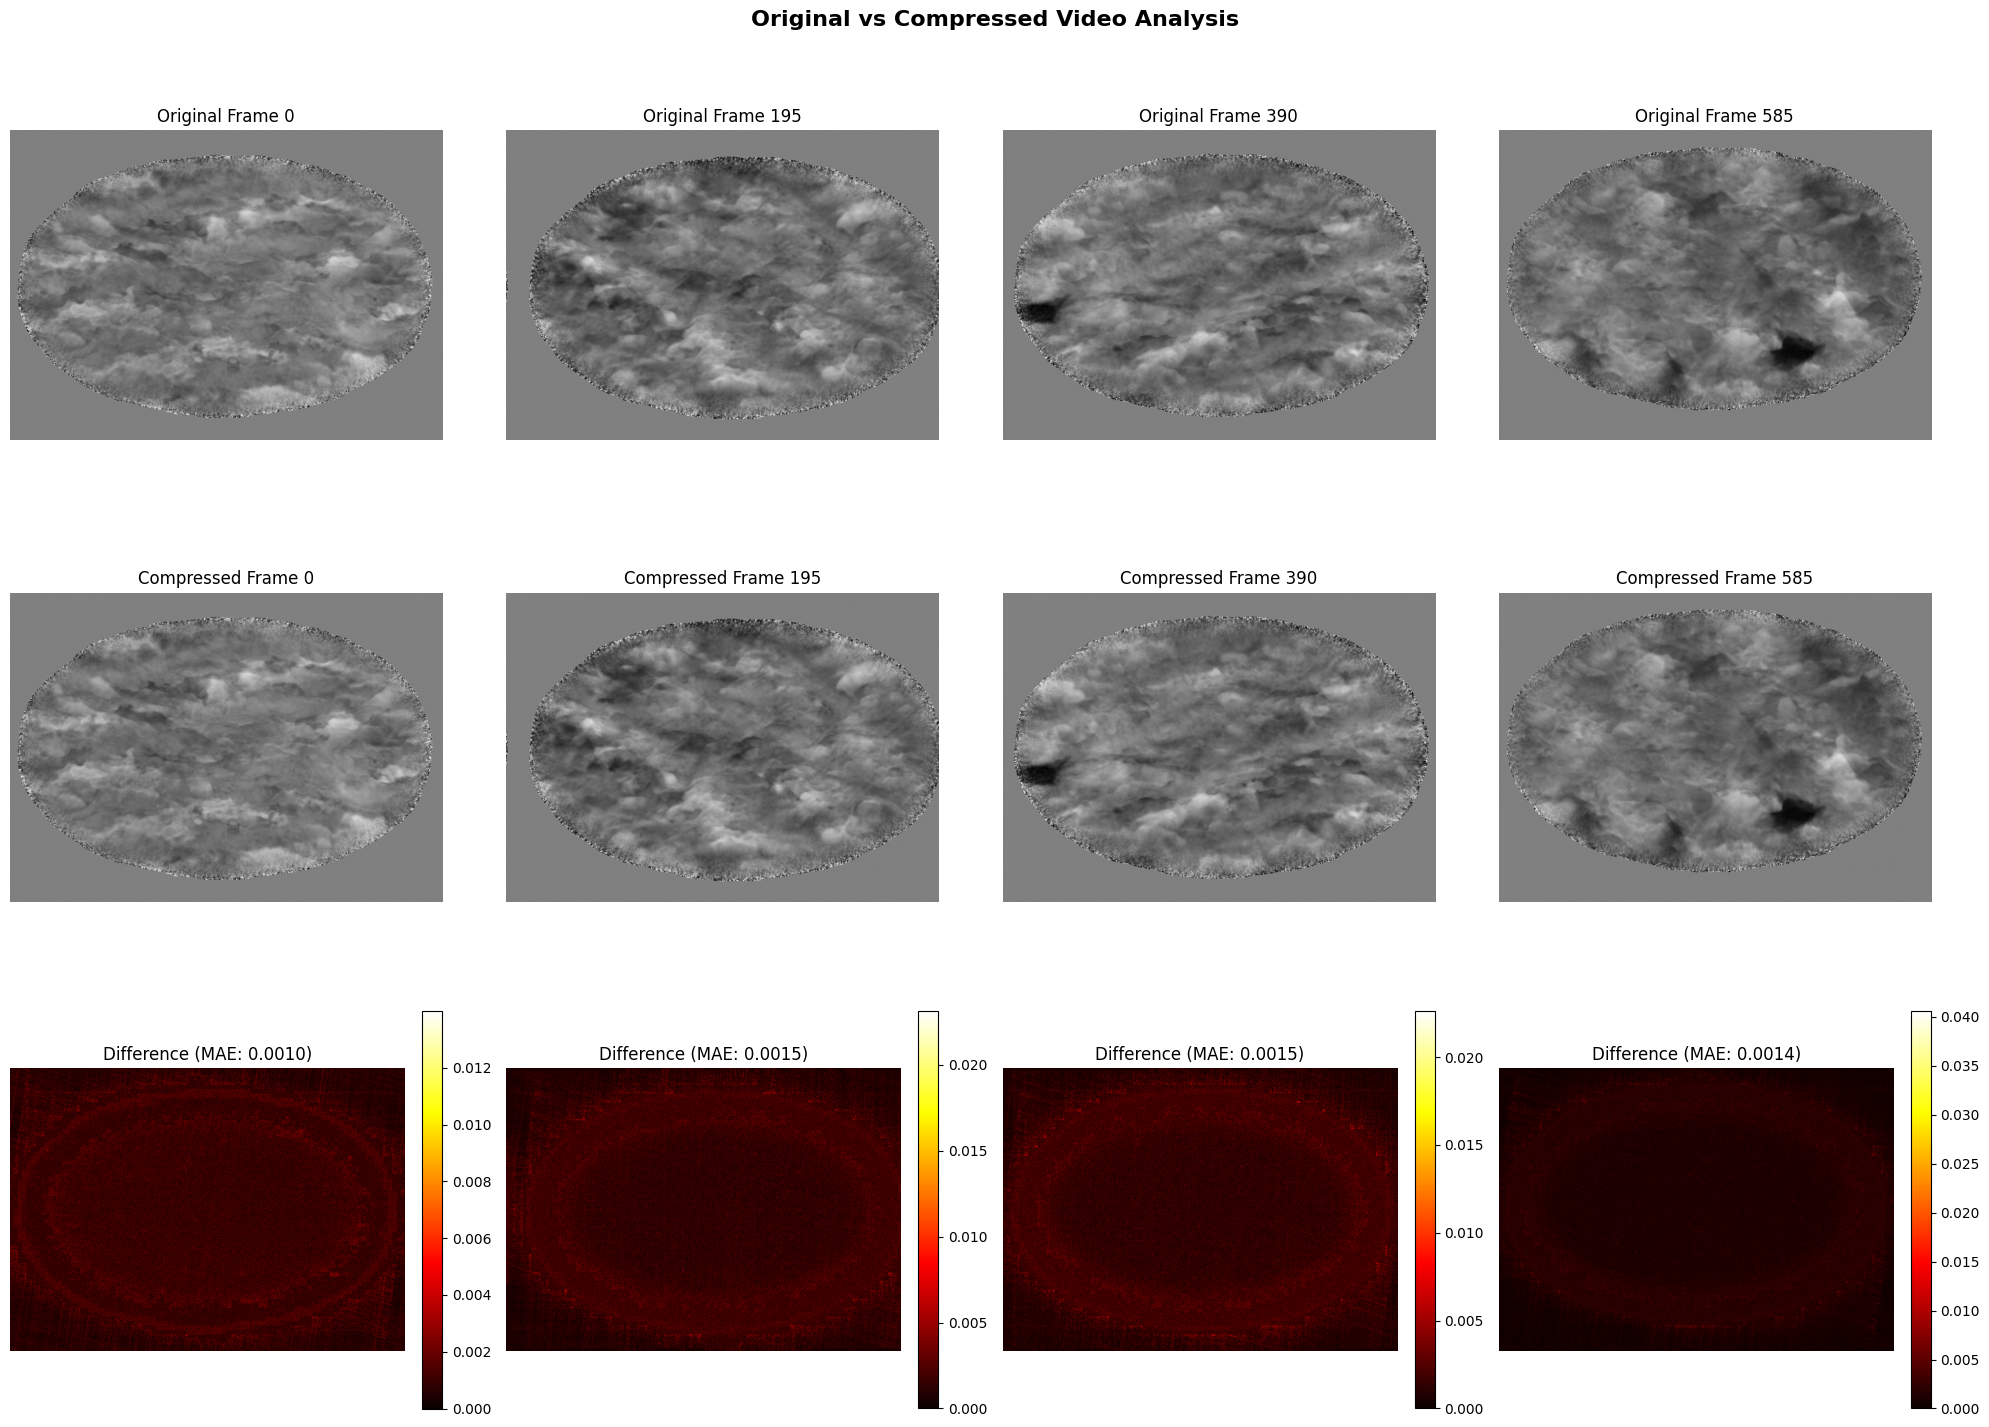

100%|██████████| 780/780 [00:03<00:00, 219.98it/s]


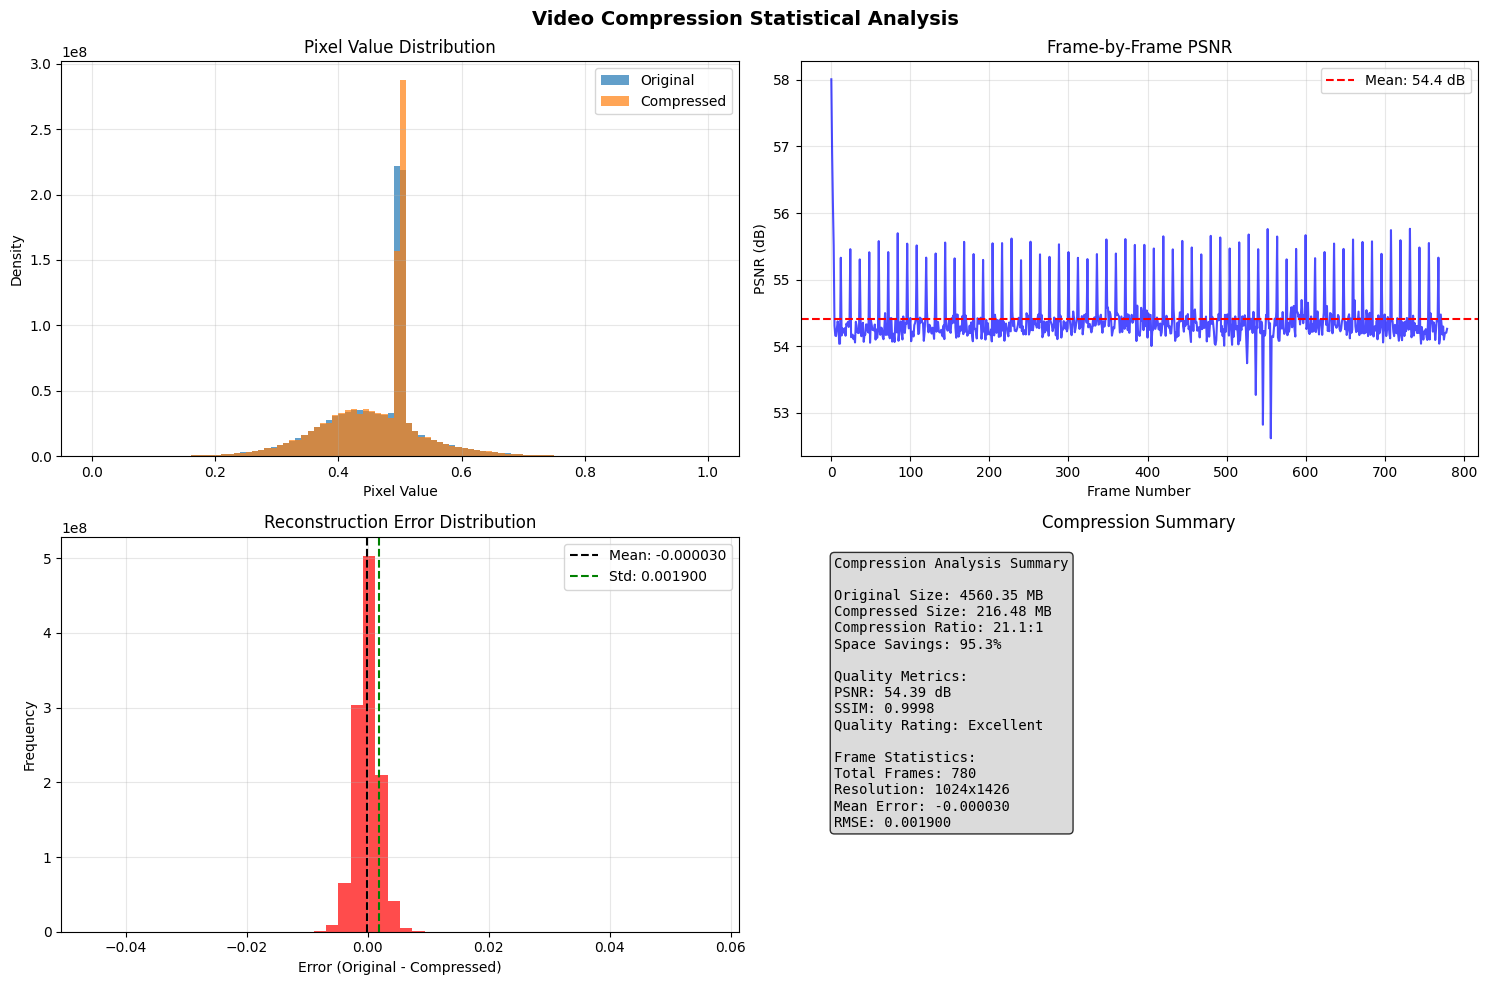

✅ Visual comparison completed


In [17]:
# Visual Comparison and Analysis
if reconstructed_video is not None:
    print("🎨 Creating Visual Comparison")
    print("=" * 40)
    
    # Create comprehensive comparison plots
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('Original vs Compressed Video Analysis', fontsize=16, fontweight='bold')
    
    # Select frames for comparison (first, middle, last few)
    comparison_frames = [0, min_frames//4, min_frames//2, 3*min_frames//4, min_frames-1]
    comparison_frames = comparison_frames[:4]  # Limit to 4 frames
    
    for i, frame_idx in enumerate(comparison_frames):
        # Original frame
        axes[0, i].imshow(original_normalized[frame_idx][5:-5, 5:-5], cmap='gray')
        axes[0, i].set_title(f'Original Frame {frame_idx}')
        axes[0, i].axis('off')
        
        # Reconstructed frame  
        axes[1, i].imshow(reconstructed_crop[frame_idx][5:-5, 5:-5], cmap='gray')
        axes[1, i].set_title(f'Compressed Frame {frame_idx}')
        axes[1, i].axis('off')
        
        # Difference map
        diff = torch.abs(original_normalized[frame_idx][5:-5, 5:-5] - reconstructed_crop[frame_idx][5:-5, 5:-5])
        im = axes[2, i].imshow(diff, cmap='hot', vmin=0, vmax=diff.max())
        axes[2, i].set_title(f'Difference (MAE: {torch.mean(diff):.4f})')
        axes[2, i].axis('off')
        
        # Add colorbar for difference maps
        plt.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical Analysis Plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Video Compression Statistical Analysis', fontsize=14, fontweight='bold')
    
    # Histogram comparison
    axes[0, 0].hist(original_normalized.flatten().numpy(), bins=100, alpha=0.7, label='Original', density=False)
    axes[0, 0].hist(reconstructed_crop.flatten().numpy(), bins=100, alpha=0.7, label='Compressed', density=False)
    axes[0, 0].set_title('Pixel Value Distribution')
    axes[0, 0].set_xlabel('Pixel Value')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Frame-by-frame PSNR
    frame_psnrs_all = []
    skip_frames = 500
    for i in tqdm(range(0, min_frames, max(1, min_frames//skip_frames))):  # Sample frames for speed
        frame_psnr = calculate_quality_metrics(original_normalized[i:i+1], reconstructed_crop[i:i+1])['psnr']
        frame_psnrs_all.append(frame_psnr)
    
    sample_frames = list(range(0, min_frames, max(1, min_frames//skip_frames)))[:len(frame_psnrs_all)]
    axes[0, 1].plot(sample_frames, frame_psnrs_all, 'b-', alpha=0.7)
    axes[0, 1].set_title('Frame-by-Frame PSNR')
    axes[0, 1].set_xlabel('Frame Number')
    axes[0, 1].set_ylabel('PSNR (dB)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=np.mean(frame_psnrs_all), color='r', linestyle='--', label=f'Mean: {np.mean(frame_psnrs_all):.1f} dB')
    axes[0, 1].legend()
    
    # Error distribution
    error = (original_normalized - reconstructed_crop).flatten()
    axes[1, 0].hist(error.numpy(), bins=50, alpha=0.7, color='red')
    axes[1, 0].set_title('Reconstruction Error Distribution')
    axes[1, 0].set_xlabel('Error (Original - Compressed)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(x=torch.mean(error).item(), color='black', linestyle='--', label=f'Mean: {torch.mean(error):.6f}')
    axes[1, 0].axvline(x=torch.std(error).item(), color='green', linestyle='--', label=f'Std: {torch.std(error):.6f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Compression metrics summary
    metrics_text = f'''Compression Analysis Summary
    
Original Size: {original_tensor_size / 1e6:.2f} MB
Compressed Size: {compressed_file_size / 1e6:.2f} MB
Compression Ratio: {compression_ratio:.1f}:1
Space Savings: {space_savings:.1f}%

Quality Metrics:
PSNR: {psnr_value:.2f} dB
SSIM: {ssim_value:.4f}
Quality Rating: {quality_rating}

Frame Statistics:
Total Frames: {min_frames}
Resolution: {min_height}x{min_width}
Mean Error: {torch.mean(error):.6f}
RMSE: {torch.sqrt(torch.mean(error**2)):.6f}'''
    
    axes[1, 1].text(0.05, 0.95, metrics_text, transform=axes[1, 1].transAxes, 
                    fontsize=10, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')
    axes[1, 1].set_title('Compression Summary')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visual comparison completed")
    
else:
    print("⚠️  Cannot create visual comparison - compressed video not loaded")

In [22]:
# Comprehensive Comparison Summary
if reconstructed_video is not None:
    print("📋 Comprehensive Comparison Summary")
    print("=" * 60)
    
    # Create summary table
    import pandas as pd
    
    # Calculate additional metrics
    mae = torch.mean(torch.abs(original_normalized - reconstructed_crop)).item()
    rmse = torch.sqrt(torch.mean((original_normalized - reconstructed_crop) ** 2)).item()
    max_error = torch.max(torch.abs(original_normalized - reconstructed_crop)).item()
    
    # Data usage efficiency
    bits_per_pixel_original = (original_tensor_size * 8) / (min_frames * min_height * min_width)
    bits_per_pixel_compressed = (compressed_file_size * 8) / (min_frames * min_height * min_width)
    
    summary_data = {
        'Metric': [
            'Original Size (MB)',
            'Compressed Size (MB)', 
            'Compression Ratio',
            'Space Savings (%)',
            'Bits per Pixel (Original)',
            'Bits per Pixel (Compressed)',
            '',  # Separator
            'PSNR (dB)',
            'SSIM',
            'Mean Absolute Error',
            'Root Mean Square Error',
            'Maximum Error',
            'Quality Rating'
        ],
        'Value': [
            f'{original_tensor_size / 1e6:.2f}',
            f'{compressed_file_size / 1e6:.2f}',
            f'{compression_ratio:.1f}:1',
            f'{space_savings:.1f}%',
            f'{bits_per_pixel_original:.2f}',
            f'{bits_per_pixel_compressed:.2f}',
            '',  # Separator
            f'{psnr_value:.2f}',
            f'{ssim_value:.4f}',
            f'{mae:.6f}',
            f'{rmse:.6f}',
            f'{max_error:.6f}',
            quality_rating
        ]
    }
    
    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False, justify='left'))
    
    # Performance evaluation
    print(f"\n🎯 Performance Evaluation:")
    print(f"   Compression Efficiency: {'Excellent' if compression_ratio > 50 else 'Very Good' if compression_ratio > 20 else 'Good' if compression_ratio > 10 else 'Moderate'}")
    print(f"   Quality Preservation: {'Excellent' if psnr_value > 40 and ssim_value > 0.95 else 'Very Good' if psnr_value > 30 and ssim_value > 0.9 else 'Good' if psnr_value > 25 else 'Fair'}")
    
    # Recommendations
    print(f"\n💡 Recommendations:")
    if compression_ratio > 20 and psnr_value > 30:
        print("   ✅ Excellent compression with high quality preservation")
        print("   ✅ Suitable for archival and analysis purposes")
    elif compression_ratio > 10 and psnr_value > 25:
        print("   ✅ Good compression with acceptable quality")
        print("   ✅ Suitable for most analysis tasks")
    elif psnr_value < 25:
        print("   ⚠️  Quality may be insufficient for detailed analysis")
        print("   💡 Consider using higher quality settings (lower CRF)")
    elif compression_ratio < 5:
        print("   ⚠️  Low compression efficiency")
        print("   💡 Consider using more aggressive compression settings")
    
    print(f"\n✅ Comprehensive analysis completed!")
    print(f"🎬 The H.265 10-bit compression achieved {compression_ratio:.1f}:1 compression")
    print(f"📊 with {psnr_value:.1f} dB PSNR and {ssim_value:.3f} SSIM quality metrics")
    
else:
    print("⚠️  Cannot create summary - compressed video not loaded")

📋 Comprehensive Comparison Summary
Metric                      Value    
         Original Size (MB)   4560.35
       Compressed Size (MB)    677.95
          Compression Ratio     6.7:1
          Space Savings (%)     85.1%
  Bits per Pixel (Original)     32.03
Bits per Pixel (Compressed)      4.76
                                     
                  PSNR (dB)     69.67
                       SSIM    1.0000
        Mean Absolute Error  0.000284
     Root Mean Square Error  0.000328
              Maximum Error  0.000618
             Quality Rating Excellent

🎯 Performance Evaluation:
   Compression Efficiency: Moderate
   Quality Preservation: Excellent

💡 Recommendations:

✅ Comprehensive analysis completed!
🎬 The H.265 10-bit compression achieved 6.7:1 compression
📊 with 69.7 dB PSNR and 1.000 SSIM quality metrics


# 10-bit Quantization Precision Loss Analysis

This section analyzes the quality loss purely from 10-bit quantization, isolating it from video compression effects.

In [14]:
# 10-bit Quantization Precision Loss Analysis
print("🔬 Analyzing Precision Loss from 10-bit Quantization")
print("=" * 60)

# Start with the original raw data (before any processing)
print(f"📊 Original raw data statistics:")
print(f"   Shape: {video_normalized.shape}")
print(f"   Data type: {video_normalized.dtype}")
print(f"   Range: [{video_normalized.min()}, {video_normalized.max()}]")

# Step 1: Convert to float32 and normalize (your exact code)
print(f"\n🔄 Step 1: Convert to float32 and normalize...")
original_float = video_normalized
print(f"   After torch conversion: range=[{original_float.min():.2f}, {original_float.max():.2f}]")

print(f"\n🔄 Step 3: Store in 16-bit container...")
video_16bit = (original_float * (2**16 - 1)).to(torch.uint16)
# video_16bit = (reconstructed_crop * (2**16 - 1)).to(torch.uint16)

print(f"   16-bit storage: range=[{video_16bit.float().min().item():.0f}, {video_16bit.float().max().item():.0f}]")
print(f"   16-bit utilization: {video_16bit.float().max().item() / 65535 * 100:.1f}%")

# Step 4: Convert back to original scale for comparison
print(f"\n🔄 Step 4: Convert back to original scale...")
# Reverse the process: 16-bit -> 10-bit -> original scale
video_back_10bit = video_16bit.float() / (2**16 - 1)

print(f"   Reconstructed: range=[{video_back_10bit.min():.2f}, {video_back_10bit.max():.2f}]")
print(f"   Original: range=[{video_normalized.min():.2f}, {video_normalized.max():.2f}]")

# Step 5: Calculate quality metrics (same as used for video compression)
print(f"\n📊 Quality Metrics Analysis:")
print("-" * 40)

# Prepare tensors for comparison (use original float32 data)
reconstructed_for_comparison = video_back_10bit   # Scale back to 16-bit range
original_for_comparison = original_float  # Scale original to 16-bit range
# Calculate MSE
mse_quantization = torch.mean((original_for_comparison - reconstructed_for_comparison) ** 2)
print(f"   Mean Squared Error: {mse_quantization.item():.6e}")

metrics = calculate_quality_metrics(original_for_comparison, reconstructed_for_comparison)
psnr_quantization = metrics['psnr']

ssim_quantization = metrics['ssim']
print(f"   PSNR: {psnr_quantization:.2f} dB")
print(f"   SSIM: {ssim_quantization:.6f}")

# Additional precision metrics
mae_quantization = torch.mean(torch.abs(original_for_comparison - reconstructed_for_comparison))
max_error_quantization = torch.max(torch.abs(original_for_comparison - reconstructed_for_comparison))
rmse_quantization = torch.sqrt(mse_quantization)

print(f"   Mean Absolute Error: {mae_quantization.item():.6e}")
print(f"   Root Mean Square Error: {rmse_quantization.item():.6e}")
print(f"   Maximum Error: {max_error_quantization.item():.6e}")

# Relative error metrics
relative_max_error = max_error_quantization / original_for_comparison.max() * 100
relative_rmse = rmse_quantization / original_for_comparison.max() * 100

print(f"   Relative Max Error: {relative_max_error.item():.4f}%")
print(f"   Relative RMSE: {relative_rmse.item():.4f}%")

# Quality assessment
print(f"\n🎯 Quality Assessment:")
print("-" * 40)

if psnr_quantization > 50:
    quality_rating = "Excellent (>50 dB)"
elif psnr_quantization > 40:
    quality_rating = "Very Good (40-50 dB)"
elif psnr_quantization > 30:
    quality_rating = "Good (30-40 dB)"
elif psnr_quantization > 20:
    quality_rating = "Fair (20-30 dB)"
else:
    quality_rating = "Poor (<20 dB)"

print(f"   PSNR Quality Rating: {quality_rating}")
print(f"   SSIM Quality: {'Excellent' if ssim_quantization > 0.95 else 'Very Good' if ssim_quantization > 0.9 else 'Good' if ssim_quantization > 0.8 else 'Fair'}")

# Bit depth utilization analysis
effective_bits = torch.log2(video_16bit.float().max() - video_16bit.float().min() + 1)
print(f"   Effective bits used: {effective_bits.item():.2f} bits")
print(f"   10-bit efficiency: {effective_bits.item() / 10 * 100:.1f}%")

print(f"\n✅ 10-bit quantization analysis completed!")
print(f"📋 Summary: PSNR = {psnr_quantization:.2f} dB, SSIM = {ssim_quantization:.6f}")

# Store results for comparison with video compression
quantization_psnr = psnr_quantization if psnr_quantization != float('inf') else 999.0
quantization_ssim = ssim_quantization
quantization_mse = mse_quantization.item()

🔬 Analyzing Precision Loss from 10-bit Quantization
📊 Original raw data statistics:
   Shape: torch.Size([2015, 864, 1344])
   Data type: torch.float32
   Range: [0.0, 1.0]

🔄 Step 1: Convert to float32 and normalize...
   After torch conversion: range=[0.00, 1.00]

🔄 Step 3: Store in 16-bit container...
   16-bit storage: range=[0, 65535]
   16-bit utilization: 100.0%

🔄 Step 4: Convert back to original scale...
   Reconstructed: range=[0.00, 1.00]
   Original: range=[0.00, 1.00]

📊 Quality Metrics Analysis:
----------------------------------------
   Mean Squared Error: 7.727619e-11
   PSNR: 101.12 dB
   SSIM: 0.999999
   Mean Absolute Error: 7.607417e-06
   Root Mean Square Error: 8.790687e-06
   Maximum Error: 1.525879e-05
   Relative Max Error: 0.0015%
   Relative RMSE: 0.0009%

🎯 Quality Assessment:
----------------------------------------
   PSNR Quality Rating: Excellent (>50 dB)
   SSIM Quality: Excellent
   Effective bits used: 16.00 bits
   10-bit efficiency: 160.0%

✅ 10-bi

📊 Visualizing 10-bit Quantization Effects


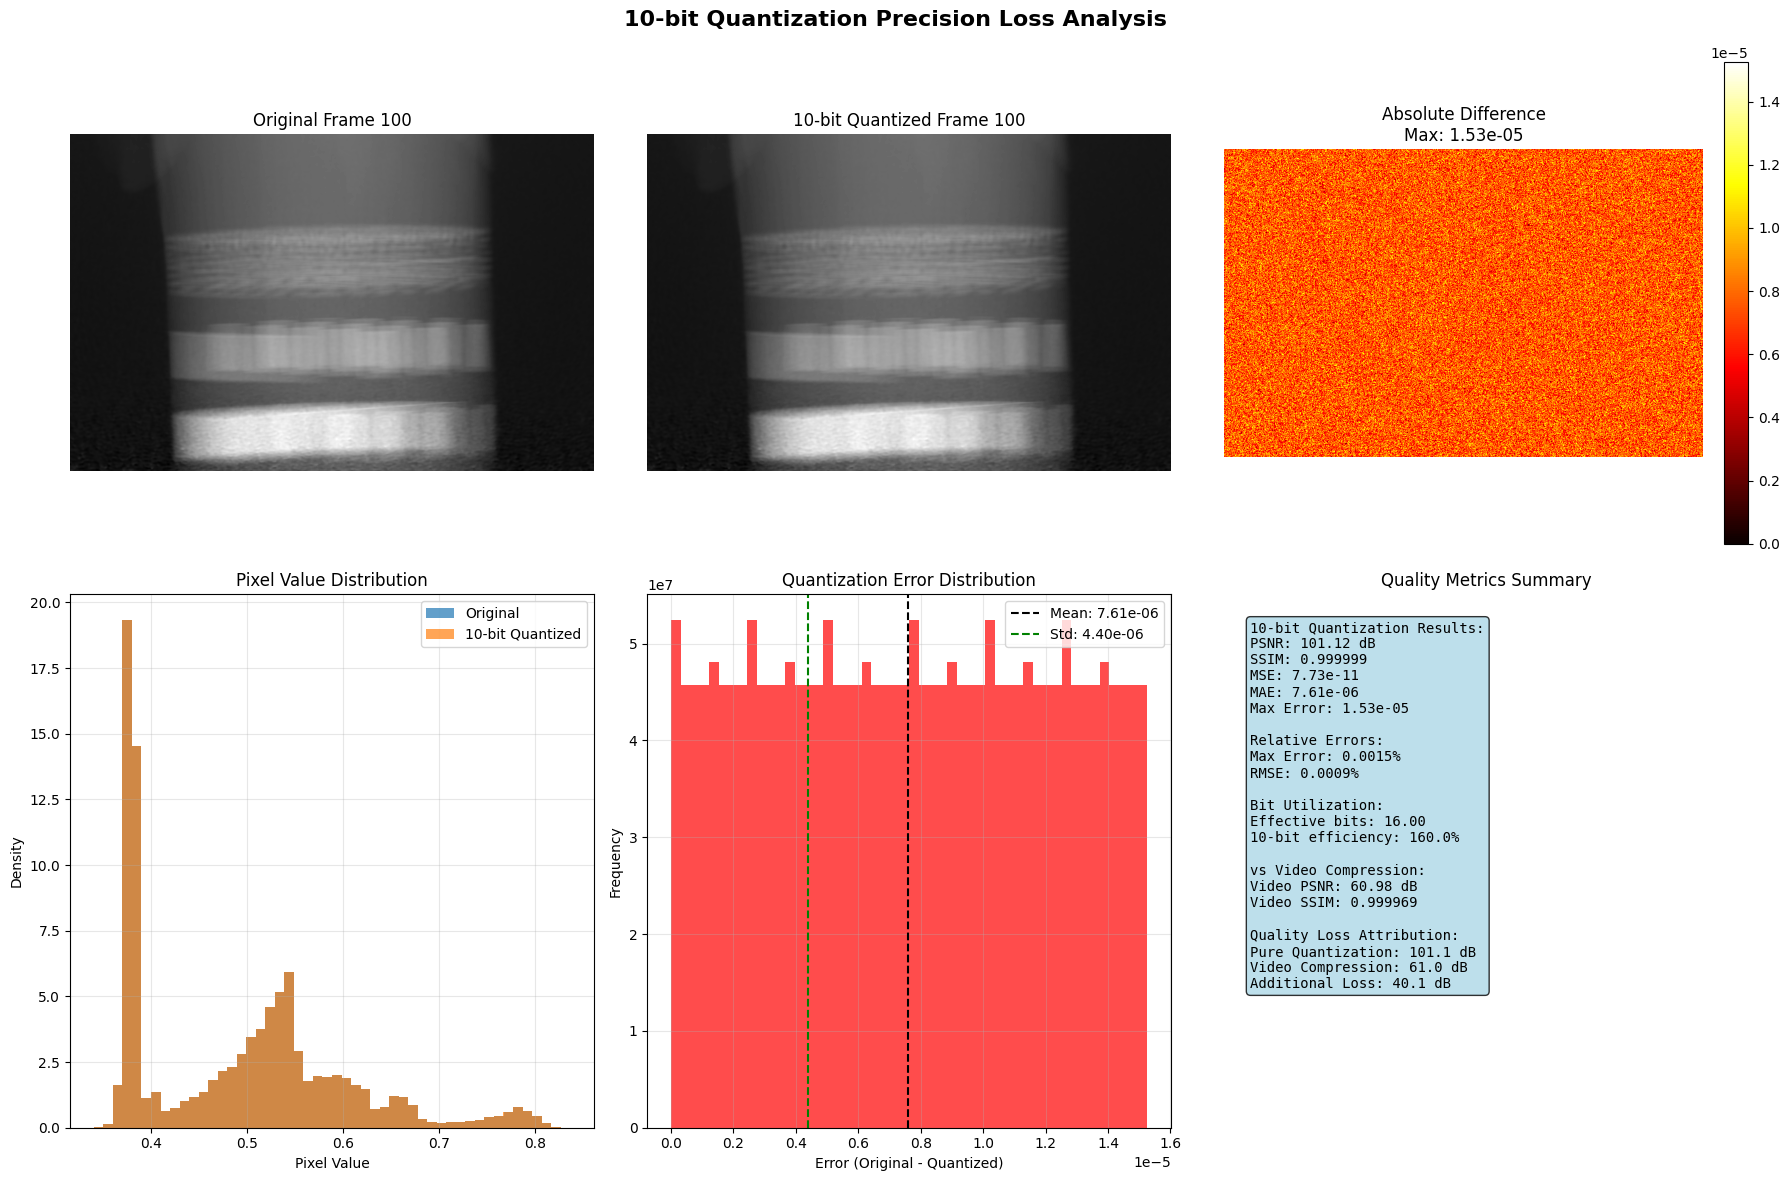


🔍 Frame-by-frame Quality Analysis (every 100th frame):
------------------------------------------------------------
   Frame   0: PSNR =  99.62 dB, SSIM = 0.999999
   Frame 100: PSNR =  99.57 dB, SSIM = 0.999999
   Frame 200: PSNR =  99.86 dB, SSIM = 0.999999
   Frame 300: PSNR = 100.19 dB, SSIM = 0.999999
   Frame 400: PSNR = 100.44 dB, SSIM = 0.999999

📈 Frame-wise Statistics:
   Mean PSNR: 99.94 ± 0.33 dB
   Mean SSIM: 0.999999 ± 0.000000

🎯 Conclusion:
   10-bit quantization alone achieves 101.1 dB PSNR
   This represents the theoretical upper bound for any 10-bit encoding
   Any additional loss in video compression is due to spatial/temporal compression
   Video compression adds 40.1 dB additional loss
   Compression efficiency: 60.3% of quantization limit

✅ Quantization precision analysis completed!


In [15]:
# Visualize 10-bit Quantization Effects
print("📊 Visualizing 10-bit Quantization Effects")
print("=" * 50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('10-bit Quantization Precision Loss Analysis', fontsize=16, fontweight='bold')

# Select a representative frame for visualization
frame_idx = min(100, original_for_comparison.shape[0] - 1)
original_frame = original_for_comparison[frame_idx]
quantized_frame = reconstructed_for_comparison[frame_idx]
difference_frame = torch.abs(original_frame - quantized_frame)

# Row 1: Original vs Quantized vs Difference
axes[0, 0].imshow(original_frame.numpy(), cmap='gray')
axes[0, 0].set_title(f'Original Frame {frame_idx}')
axes[0, 0].axis('off')

axes[0, 1].imshow(quantized_frame.numpy(), cmap='gray')
axes[0, 1].set_title(f'10-bit Quantized Frame {frame_idx}')
axes[0, 1].axis('off')

im_diff = axes[0, 2].imshow(difference_frame.numpy(), cmap='hot')
axes[0, 2].set_title(f'Absolute Difference\nMax: {difference_frame.max():.2e}')
axes[0, 2].axis('off')
plt.colorbar(im_diff, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Row 2: Statistical analyses
# Histogram comparison
axes[1, 0].hist(original_frame.flatten().numpy(), bins=50, alpha=0.7, label='Original', density=True)
axes[1, 0].hist(quantized_frame.flatten().numpy(), bins=50, alpha=0.7, label='10-bit Quantized', density=True)
axes[1, 0].set_title('Pixel Value Distribution')
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error histogram
error_flat = (original_for_comparison - reconstructed_for_comparison).flatten()
axes[1, 1].hist(error_flat.numpy(), bins=50, alpha=0.7, color='red')
axes[1, 1].set_title('Quantization Error Distribution')
axes[1, 1].set_xlabel('Error (Original - Quantized)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=torch.mean(error_flat).item(), color='black', linestyle='--', 
                   label=f'Mean: {torch.mean(error_flat).item():.2e}')
axes[1, 1].axvline(x=torch.std(error_flat).item(), color='green', linestyle='--', 
                   label=f'Std: {torch.std(error_flat).item():.2e}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Comparison with video compression (if available)
comparison_text = f'''10-bit Quantization Results:
PSNR: {quantization_psnr:.2f} dB
SSIM: {quantization_ssim:.6f}
MSE: {quantization_mse:.2e}
MAE: {mae_quantization.item():.2e}
Max Error: {max_error_quantization.item():.2e}

Relative Errors:
Max Error: {relative_max_error.item():.4f}%
RMSE: {relative_rmse.item():.4f}%

Bit Utilization:
Effective bits: {effective_bits.item():.2f}
10-bit efficiency: {effective_bits.item() / 10 * 100:.1f}%'''

# Add video compression comparison if available
if 'psnr_value' in locals() and 'ssim_value' in locals():
    comparison_text += f'''

vs Video Compression:
Video PSNR: {psnr_value:.2f} dB
Video SSIM: {ssim_value:.6f}

Quality Loss Attribution:
Pure Quantization: {quantization_psnr:.1f} dB
Video Compression: {psnr_value:.1f} dB
Additional Loss: {quantization_psnr - psnr_value:.1f} dB'''

axes[1, 2].text(0.05, 0.95, comparison_text, transform=axes[1, 2].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].axis('off')
axes[1, 2].set_title('Quality Metrics Summary')

plt.tight_layout()
plt.show()

# Frame-by-frame analysis for better understanding - using centralized function
print(f"\n🔍 Frame-by-frame Quality Analysis (every 100th frame):")
print("-" * 60)

frame_psnrs_quant = []
frame_ssims_quant = []
sample_frames_quant = []

for i in range(0, min(500, original_for_comparison.shape[0]), 100):
    orig_frame = original_for_comparison[i]
    quant_frame = reconstructed_for_comparison[i]
    
    # Use centralized quality metrics function
    frame_metrics = calculate_quality_metrics(orig_frame, quant_frame)
    
    frame_psnrs_quant.append(frame_metrics['psnr'])
    frame_ssims_quant.append(frame_metrics['ssim'])
    sample_frames_quant.append(i)
    
    print(f"   Frame {i:3d}: PSNR = {frame_metrics['psnr']:6.2f} dB, SSIM = {frame_metrics['ssim']:.6f}")

# Overall statistics
if len(frame_psnrs_quant) > 0:
    mean_frame_psnr = np.mean([p for p in frame_psnrs_quant if p < 900])  # Exclude inf values
    mean_frame_ssim = np.mean(frame_ssims_quant)
    std_frame_psnr = np.std([p for p in frame_psnrs_quant if p < 900])
    std_frame_ssim = np.std(frame_ssims_quant)
    
    print(f"\n📈 Frame-wise Statistics:")
    print(f"   Mean PSNR: {mean_frame_psnr:.2f} ± {std_frame_psnr:.2f} dB")
    print(f"   Mean SSIM: {mean_frame_ssim:.6f} ± {std_frame_ssim:.6f}")

print(f"\n🎯 Conclusion:")
print(f"   10-bit quantization alone achieves {quantization_psnr:.1f} dB PSNR")
print(f"   This represents the theoretical upper bound for any 10-bit encoding")
print(f"   Any additional loss in video compression is due to spatial/temporal compression")

if 'psnr_value' in locals():
    additional_loss = quantization_psnr - psnr_value
    if additional_loss > 0:
        print(f"   Video compression adds {additional_loss:.1f} dB additional loss")
        print(f"   Compression efficiency: {psnr_value/quantization_psnr*100:.1f}% of quantization limit")
    else:
        print(f"   Video compression performs better than pure quantization (unexpected!)")

print(f"\n✅ Quantization precision analysis completed!")

# 7. FBP Reconstruction and Comparison

Perform Filtered Back Projection (FBP) reconstruction using both the original and reconstructed sinograms to evaluate the impact of compression on the final reconstructed volume.

In [12]:
## FBP Reconstruction Comparison for Single Slice

### Comparing the impact of compression on FBP reconstruction for a single slice from the sinogram data.

from skimage.transform import iradon

def compute_slice_fbp_reconstruction(slice_idx, video_normalized, reconstructed_video, angles, visualize=True):
    """
    Compute FBP reconstruction for a single slice and return quality metrics.
    
    Args:
        slice_idx (int): Index of the slice to reconstruct
        video_normalized (torch.Tensor): Original normalized video tensor
        reconstructed_video (torch.Tensor): Reconstructed video tensor after compression
        angles (np.ndarray): Projection angles
        visualize (bool): Whether to show visualization plots
    
    Returns:
        dict: Dictionary containing reconstruction results and quality metrics
    """
    
    # Extract sinograms for the selected slice
    original_sinogram = video_normalized[:, slice_idx, :].numpy()  # Shape: (n_angles, n_detectors)
    reconstructed_sinogram = reconstructed_video[:, slice_idx, :].numpy()

    if visualize:
        print(f"Analyzing slice {slice_idx}")
        print(f"Original sinogram shape: {original_sinogram.shape}")
        print(f"Reconstructed sinogram shape: {reconstructed_sinogram.shape}")
        print(f"Angles shape: {angles.shape}")

    # Convert angles to degrees and flatten
    angles_deg = angles.flatten() * 180 / np.pi if angles.max() <= np.pi else angles.flatten()
    if visualize:
        print(f"Angle range: [{angles_deg.min():.2f}, {angles_deg.max():.2f}] degrees")

    # Perform FBP reconstruction using scikit-image
    # Note: iradon expects sinogram shape (n_detectors, n_angles)
    original_sino_transposed = original_sinogram.T
    reconstructed_sino_transposed = reconstructed_sinogram.T

    if visualize:
        print(f"Transposed sinogram shapes for iradon: {original_sino_transposed.shape}")

    # FBP reconstruction
    if visualize:
        print("Performing FBP reconstruction on original sinogram...")
    fbp_original = iradon(original_sino_transposed, theta=angles_deg, 
                         filter_name='ramp', interpolation='linear')

    if visualize:
        print("Performing FBP reconstruction on compressed sinogram...")
    fbp_reconstructed = iradon(reconstructed_sino_transposed, theta=angles_deg,
                              filter_name='ramp', interpolation='linear')

    if visualize:
        print(f"FBP reconstruction shapes: {fbp_original.shape}, {fbp_reconstructed.shape}")

    # Calculate PSNR between the two reconstructions
    mse_fbp = np.mean((fbp_original - fbp_reconstructed) ** 2)
    if mse_fbp > 0:
        max_val = np.max(fbp_original)
        psnr_fbp = 20 * np.log10(max_val / np.sqrt(mse_fbp))
    else:
        psnr_fbp = float('inf')

    if visualize:
        print(f"\nFBP Reconstruction PSNR for slice {slice_idx}: {psnr_fbp:.2f} dB")

    # Calculate additional quality metrics
    mae_fbp = np.mean(np.abs(fbp_original - fbp_reconstructed))
    ncc_fbp = np.corrcoef(fbp_original.flatten(), fbp_reconstructed.flatten())[0, 1]
    
    # Calculate SSIM (Structural Similarity Index)
    def calculate_ssim(img1, img2):
        """Calculate SSIM between two images"""
        mu1 = np.mean(img1)
        mu2 = np.mean(img2)
        sigma1 = np.var(img1)
        sigma2 = np.var(img2)
        sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
        
        c1 = (0.01 * np.max(img1)) ** 2
        c2 = (0.03 * np.max(img1)) ** 2
        
        ssim = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))
        return ssim
    
    ssim_fbp = calculate_ssim(fbp_original, fbp_reconstructed)
    
    fbp_diff = np.abs(fbp_original - fbp_reconstructed)
    sino_diff = np.abs(original_sinogram - reconstructed_sinogram)

    # Visualization
    if visualize:
        # Visualize the results
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Original sinogram
        im1 = axes[0, 0].imshow(original_sinogram, cmap='gray', aspect='auto')
        axes[0, 0].set_title(f'Original Sinogram\n(Slice {slice_idx})')
        axes[0, 0].set_xlabel('Detector Position')
        axes[0, 0].set_ylabel('Projection Angle')
        plt.colorbar(im1, ax=axes[0, 0])

        # Reconstructed sinogram
        im2 = axes[0, 1].imshow(reconstructed_sinogram, cmap='gray', aspect='auto')
        axes[0, 1].set_title(f'Compressed Sinogram\n(Slice {slice_idx})')
        axes[0, 1].set_xlabel('Detector Position')
        axes[0, 1].set_ylabel('Projection Angle')
        plt.colorbar(im2, ax=axes[0, 1])

        # Sinogram difference
        im3 = axes[0, 2].imshow(sino_diff, cmap='hot', aspect='auto')
        axes[0, 2].set_title('Sinogram Difference\n(Absolute)')
        axes[0, 2].set_xlabel('Detector Position')
        axes[0, 2].set_ylabel('Projection Angle')
        plt.colorbar(im3, ax=axes[0, 2])

        # Original FBP reconstruction
        im4 = axes[1, 0].imshow(fbp_original, cmap='gray')
        axes[1, 0].set_title('FBP Reconstruction\n(Original)')
        axes[1, 0].axis('off')
        plt.colorbar(im4, ax=axes[1, 0])

        # Compressed FBP reconstruction
        im5 = axes[1, 1].imshow(fbp_reconstructed, cmap='gray')
        axes[1, 1].set_title('FBP Reconstruction\n(Compressed)')
        axes[1, 1].axis('off')
        plt.colorbar(im5, ax=axes[1, 1])

        # FBP difference
        im6 = axes[1, 2].imshow(fbp_diff, cmap='hot')
        axes[1, 2].set_title(f'FBP Difference\nPSNR: {psnr_fbp:.2f} dB, SSIM: {ssim_fbp:.3f}')
        axes[1, 2].axis('off')
        plt.colorbar(im6, ax=axes[1, 2])

        plt.tight_layout()
        plt.show()

        print(f"\nDetailed Quality Metrics for Slice {slice_idx}:")
        print(f"  PSNR: {psnr_fbp:.2f} dB")
        print(f"  MSE: {mse_fbp:.6f}")
        print(f"  MAE: {mae_fbp:.6f}")
        print(f"  SSIM: {ssim_fbp:.6f}")
        print(f"  Cross-Correlation: {ncc_fbp:.6f}")
        print(f"  Max FBP difference: {np.max(fbp_diff):.6f}")
        print(f"  Mean sinogram difference: {np.mean(sino_diff):.6f}")

    # Return results as dictionary
    return {
        'slice_idx': slice_idx,
        'fbp_original': fbp_original,
        'fbp_reconstructed': fbp_reconstructed,
        'original_sinogram': original_sinogram,
        'reconstructed_sinogram': reconstructed_sinogram,
        'psnr_fbp': psnr_fbp,
        'mse_fbp': mse_fbp,
        'mae_fbp': mae_fbp,
        'ssim_fbp': ssim_fbp,
        'ncc_fbp': ncc_fbp,
        'sino_diff_mean': np.mean(sino_diff),
        'fbp_diff_max': np.max(fbp_diff)
    }

Analyzing slice 300
Original sinogram shape: (2015, 1344)
Reconstructed sinogram shape: (2015, 1344)
Angles shape: (2015, 1)
Angle range: [0.10, 180.10] degrees
Transposed sinogram shapes for iradon: (1344, 2015)
Performing FBP reconstruction on original sinogram...
Performing FBP reconstruction on compressed sinogram...
FBP reconstruction shapes: (1344, 1344), (1344, 1344)

FBP Reconstruction PSNR for slice 300: 63.61 dB


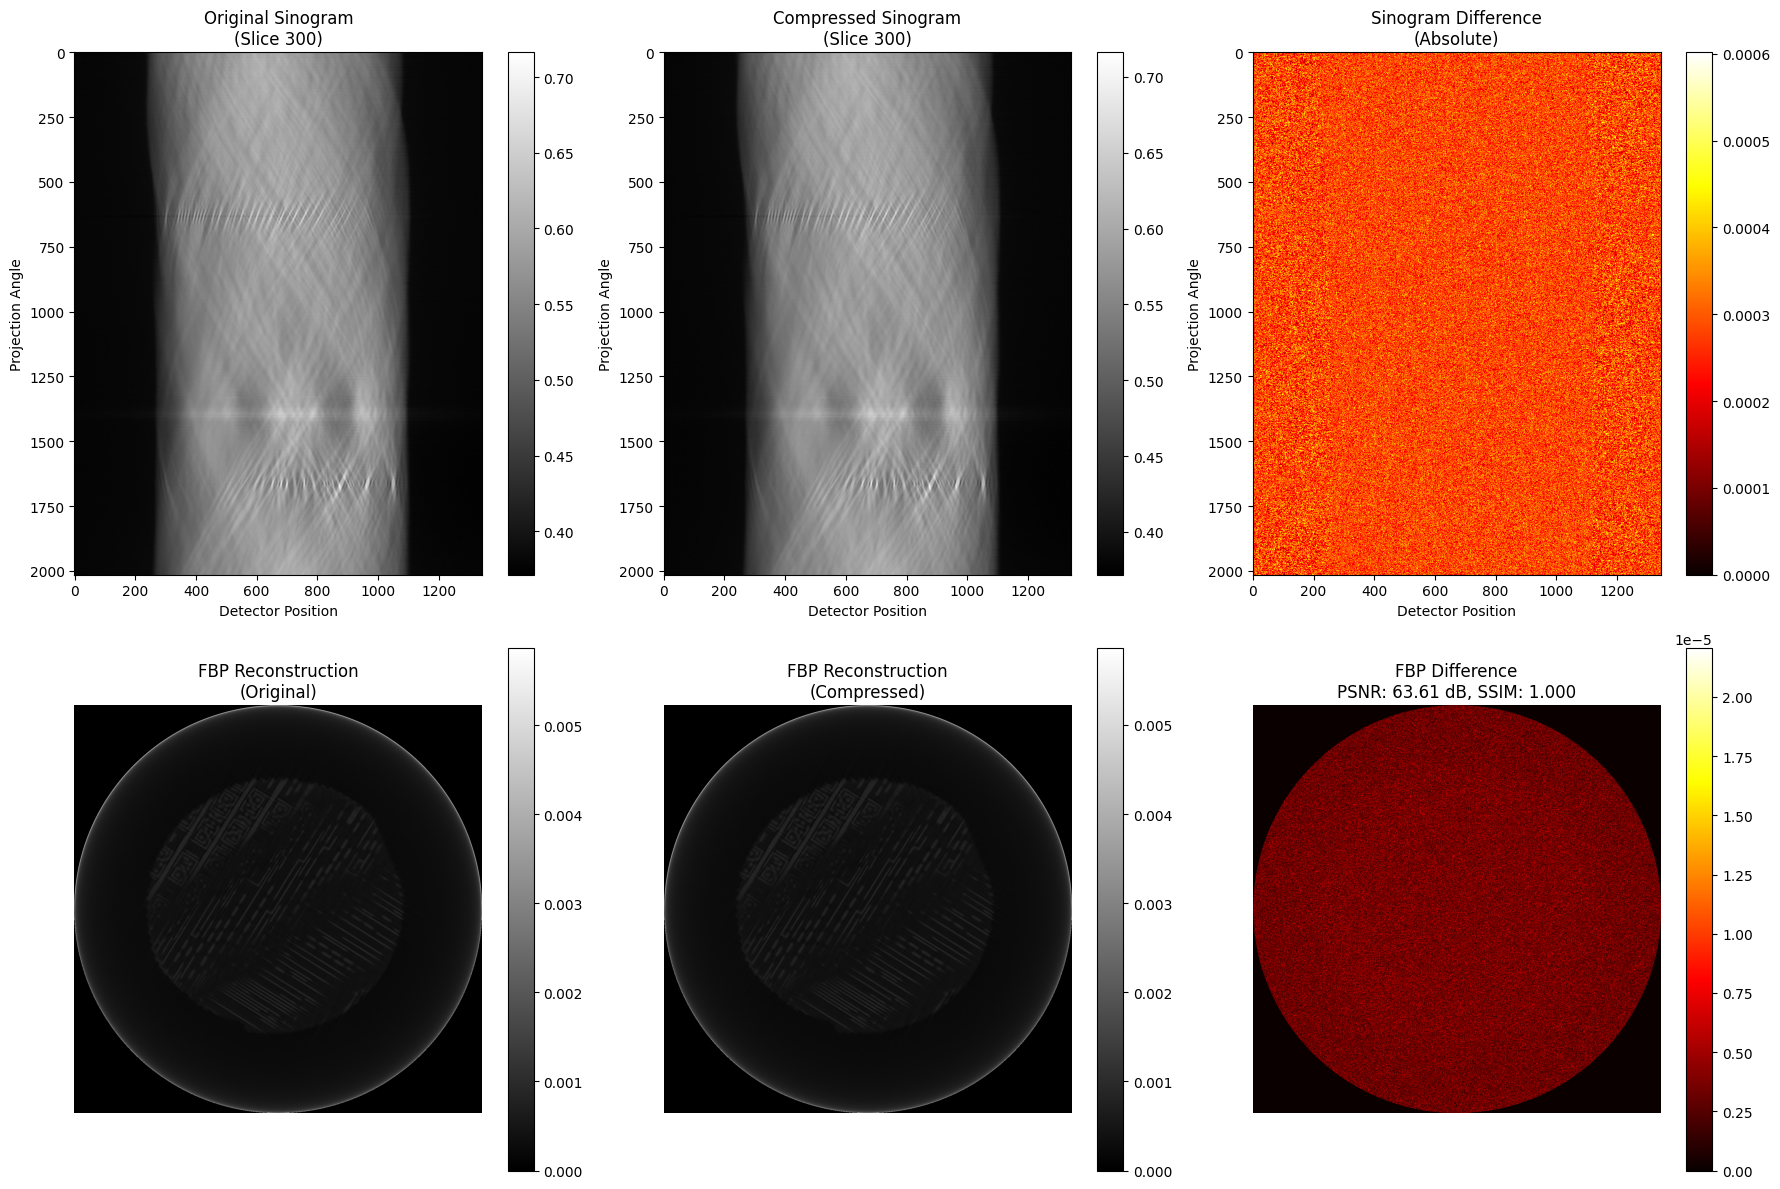


Detailed Quality Metrics for Slice 300:
  PSNR: 63.61 dB
  MSE: 0.000000
  MAE: 0.000003
  SSIM: 0.999946
  Cross-Correlation: 0.999940
  Max FBP difference: 0.000022
  Mean sinogram difference: 0.000285


In [13]:
# Test the function with the previous example
slice_idx = 300
result = compute_slice_fbp_reconstruction(slice_idx, video_normalized, reconstructed_video, angles, visualize=True)

Computing FBP reconstruction for 201 slices (range: 200-400)
This may take several minutes...


Processing slices:   0%|          | 0/201 [00:00<?, ?it/s]


Volume shapes:
  Original volume: (201, 1344, 1344)
  Reconstructed volume: (201, 1344, 1344)

🎯 Volume Quality Metrics:
Volume PSNR (VPSNR): 63.66 dB
Volume SSIM: 0.999945
Volume MSE: 0.000000
Volume MAE: 0.000003
Volume Cross-Correlation: 0.999941

📊 Slice-level Statistics:
  Mean slice PSNR: 63.62 ± 0.06 dB
  Min slice PSNR: 63.51 dB (slice 399)
  Max slice PSNR: 63.78 dB (slice 202)
  Mean slice SSIM: 0.9999 ± 0.0000
  Min slice SSIM: 0.9999 (slice 227)
  Max slice SSIM: 0.9999 (slice 261)


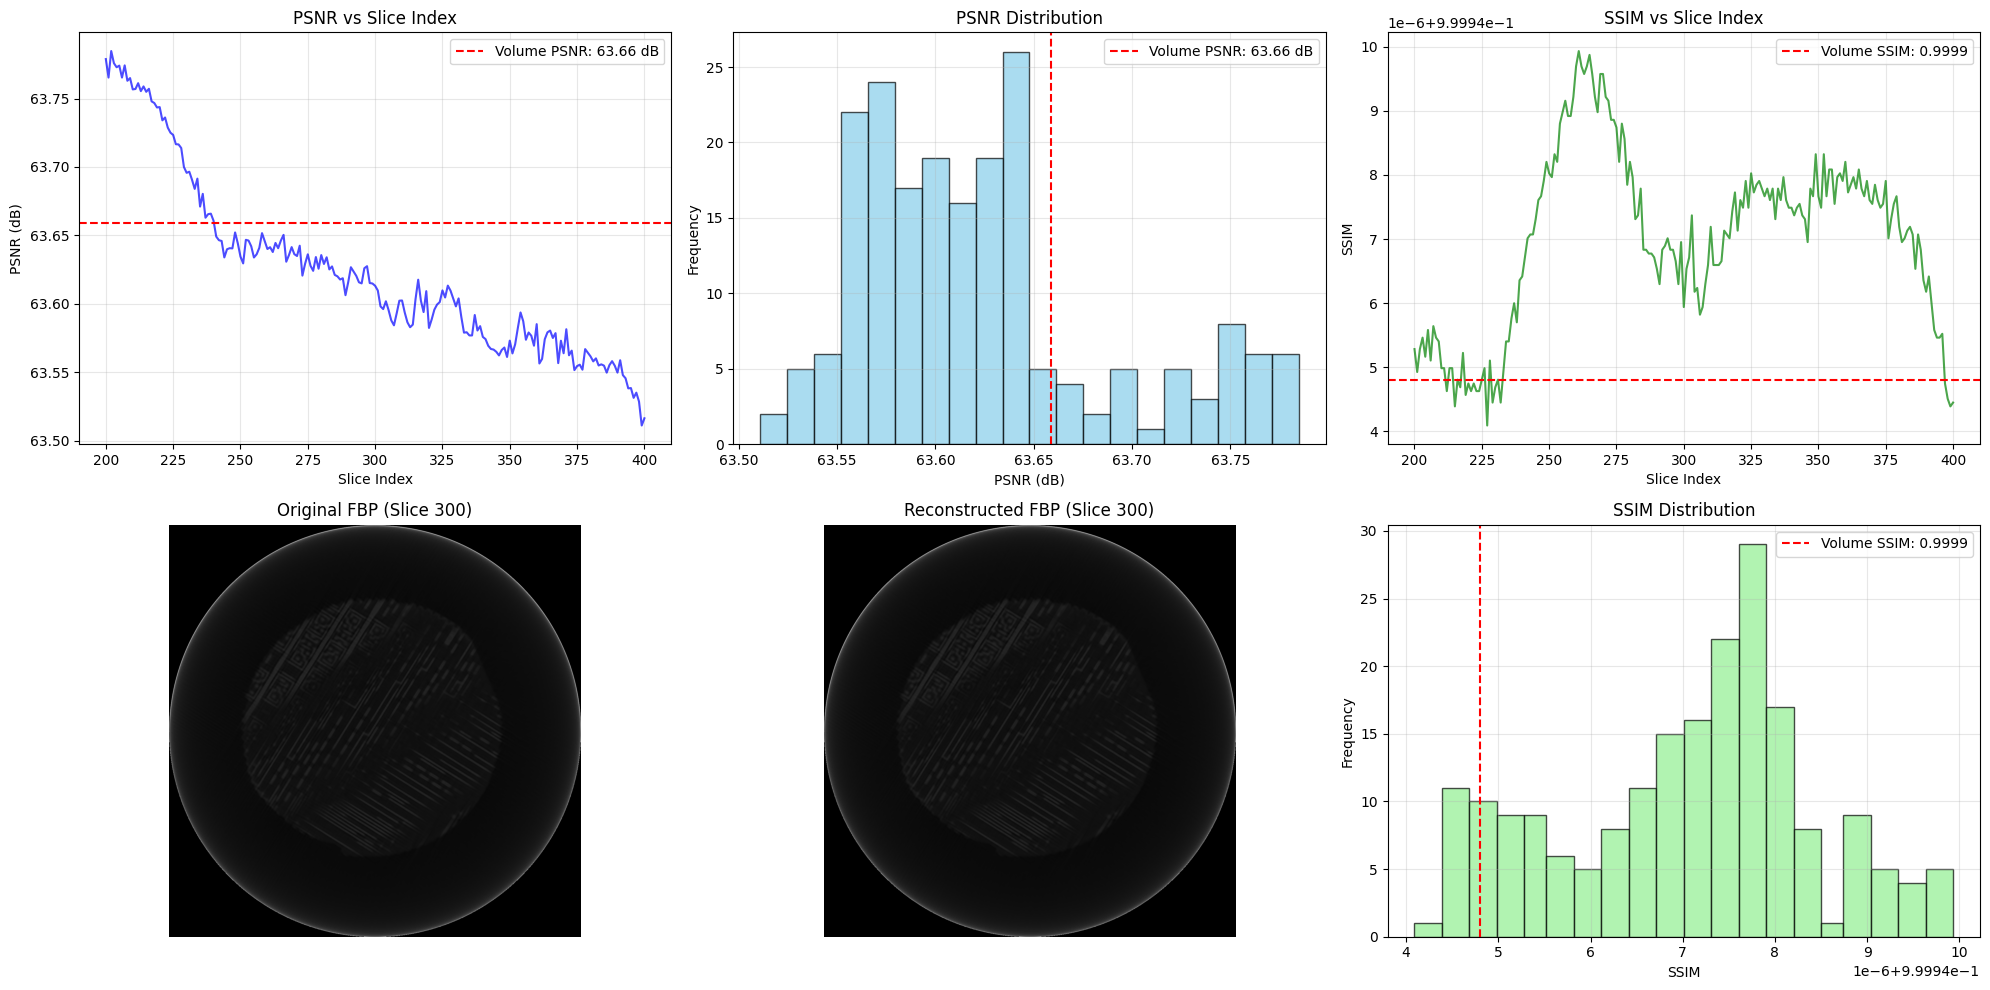

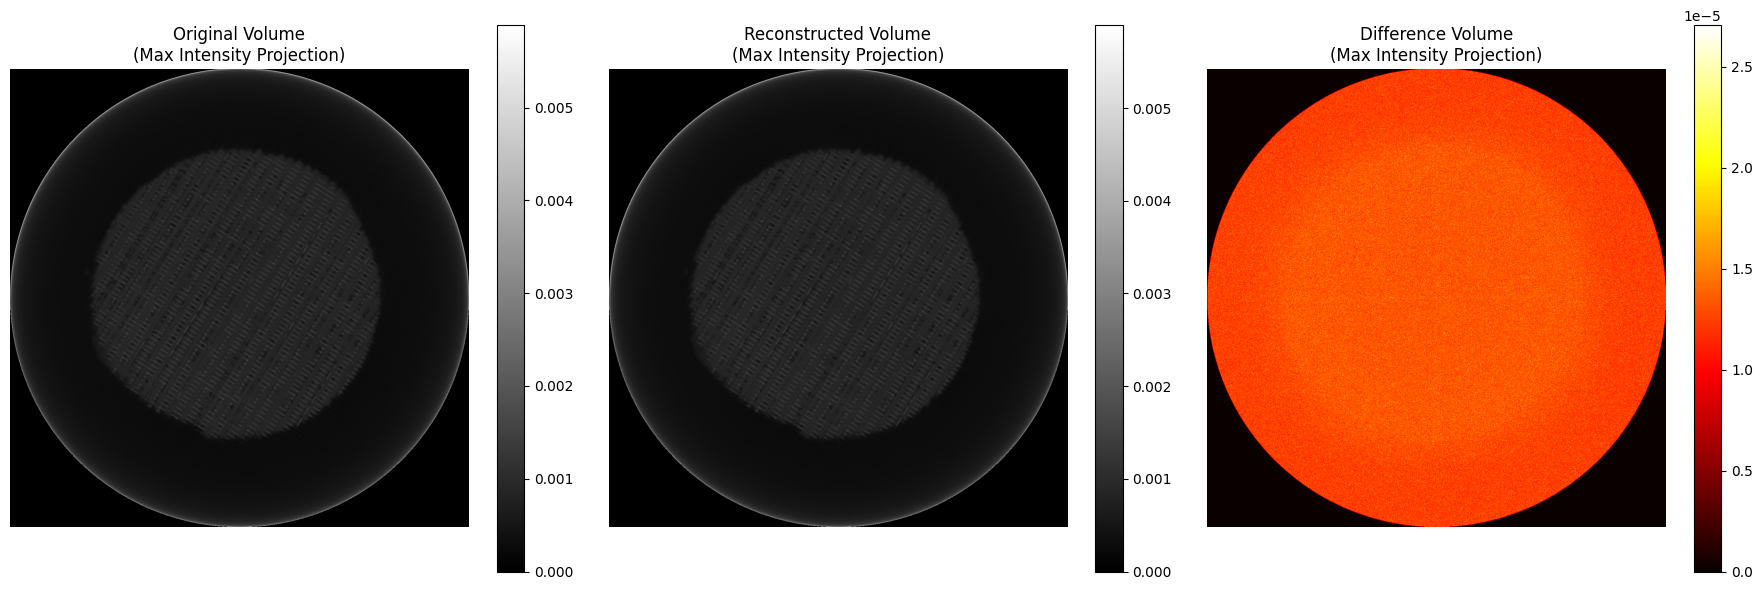


✅ Volume reconstruction complete!
   Range: slices 200-400 (201 slices)
   Volume PSNR: 63.66 dB
   Volume SSIM: 0.9999
   Volume shape: (201, 1344, 1344)
   Memory usage: ~1452.3 MB per volume


In [14]:
## Volume FBP Reconstruction and VPSNR Analysis

# Define slice range - can be modified as needed
slice_start = 200
slice_end = 400
slice_range = range(slice_start, slice_end + 1)
n_slices = len(slice_range)

print(f"Computing FBP reconstruction for {n_slices} slices (range: {slice_start}-{slice_end})")
print("This may take several minutes...")

# Initialize arrays to store the reconstructed volumes
volume_original = []
volume_reconstructed = []
slice_metrics = []

# Process each slice
from tqdm.auto import tqdm

for i, slice_idx in enumerate(tqdm(slice_range, desc="Processing slices")):
    # Compute FBP reconstruction for this slice (without visualization)
    result = compute_slice_fbp_reconstruction(
        slice_idx, video_normalized, reconstructed_video, angles, visualize=False
    )
    
    # Store the reconstructed slices
    volume_original.append(result['fbp_original'])
    volume_reconstructed.append(result['fbp_reconstructed'])
    
    # Store slice-level metrics
    slice_metrics.append({
        'slice_idx': slice_idx,
        'psnr': result['psnr_fbp'],
        'mse': result['mse_fbp'],
        'mae': result['mae_fbp'],
        'ssim': result['ssim_fbp'],
        'ncc': result['ncc_fbp']
    })

# Convert to numpy arrays for volume operations
volume_original = np.stack(volume_original, axis=0)  # Shape: (n_slices, height, width)
volume_reconstructed = np.stack(volume_reconstructed, axis=0)

print(f"\nVolume shapes:")
print(f"  Original volume: {volume_original.shape}")
print(f"  Reconstructed volume: {volume_reconstructed.shape}")

# Calculate Volume PSNR (VPSNR)
volume_mse = np.mean((volume_original - volume_reconstructed) ** 2)
if volume_mse > 0:
    max_val = np.max(volume_original)
    vpsnr = 20 * np.log10(max_val / np.sqrt(volume_mse))
else:
    vpsnr = float('inf')

# Calculate additional volume metrics
volume_mae = np.mean(np.abs(volume_original - volume_reconstructed))
volume_ncc = np.corrcoef(volume_original.flatten(), volume_reconstructed.flatten())[0, 1]

# Calculate Volume SSIM
def calculate_volume_ssim(vol1, vol2):
    """Calculate SSIM for entire volume"""
    mu1 = np.mean(vol1)
    mu2 = np.mean(vol2)
    sigma1 = np.var(vol1)
    sigma2 = np.var(vol2)
    sigma12 = np.mean((vol1 - mu1) * (vol2 - mu2))
    
    c1 = (0.01 * np.max(vol1)) ** 2
    c2 = (0.03 * np.max(vol1)) ** 2
    
    ssim = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))
    return ssim

volume_ssim = calculate_volume_ssim(volume_original, volume_reconstructed)

print(f"\n🎯 Volume Quality Metrics:")
print(f"=" * 50)
print(f"Volume PSNR (VPSNR): {vpsnr:.2f} dB")
print(f"Volume SSIM: {volume_ssim:.6f}")
print(f"Volume MSE: {volume_mse:.6f}")
print(f"Volume MAE: {volume_mae:.6f}")
print(f"Volume Cross-Correlation: {volume_ncc:.6f}")

# Calculate slice-level statistics
slice_psnrs = [m['psnr'] for m in slice_metrics]
slice_mses = [m['mse'] for m in slice_metrics]
slice_maes = [m['mae'] for m in slice_metrics]
slice_ssims = [m['ssim'] for m in slice_metrics]

print(f"\n📊 Slice-level Statistics:")
print(f"  Mean slice PSNR: {np.mean(slice_psnrs):.2f} ± {np.std(slice_psnrs):.2f} dB")
print(f"  Min slice PSNR: {np.min(slice_psnrs):.2f} dB (slice {slice_range[np.argmin(slice_psnrs)]})")
print(f"  Max slice PSNR: {np.max(slice_psnrs):.2f} dB (slice {slice_range[np.argmax(slice_psnrs)]})")
print(f"  Mean slice SSIM: {np.mean(slice_ssims):.4f} ± {np.std(slice_ssims):.4f}")
print(f"  Min slice SSIM: {np.min(slice_ssims):.4f} (slice {slice_range[np.argmin(slice_ssims)]})")
print(f"  Max slice SSIM: {np.max(slice_ssims):.4f} (slice {slice_range[np.argmax(slice_ssims)]})")

# Visualize slice-level PSNR and SSIM distribution
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# PSNR vs slice index
axes[0, 0].plot(slice_range, slice_psnrs, 'b-', alpha=0.7)
axes[0, 0].set_xlabel('Slice Index')
axes[0, 0].set_ylabel('PSNR (dB)')
axes[0, 0].set_title('PSNR vs Slice Index')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=vpsnr, color='r', linestyle='--', label=f'Volume PSNR: {vpsnr:.2f} dB')
axes[0, 0].legend()

# PSNR histogram
axes[0, 1].hist(slice_psnrs, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].set_xlabel('PSNR (dB)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('PSNR Distribution')
axes[0, 1].axvline(x=vpsnr, color='r', linestyle='--', label=f'Volume PSNR: {vpsnr:.2f} dB')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# SSIM vs slice index
axes[0, 2].plot(slice_range, slice_ssims, 'g-', alpha=0.7)
axes[0, 2].set_xlabel('Slice Index')
axes[0, 2].set_ylabel('SSIM')
axes[0, 2].set_title('SSIM vs Slice Index')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=volume_ssim, color='r', linestyle='--', label=f'Volume SSIM: {volume_ssim:.4f}')
axes[0, 2].legend()

# Show sample slices from the volume
sample_slice_indices = [0, n_slices//4, n_slices//2, 3*n_slices//4, n_slices-1]
diff_volume = np.abs(volume_original - volume_reconstructed)

# Original vs reconstructed comparison for middle slice
mid_slice = n_slices // 2
axes[1, 0].imshow(volume_original[mid_slice], cmap='gray')
axes[1, 0].set_title(f'Original FBP (Slice {slice_range[mid_slice]})')
axes[1, 0].axis('off')

axes[1, 1].imshow(volume_reconstructed[mid_slice], cmap='gray')
axes[1, 1].set_title(f'Reconstructed FBP (Slice {slice_range[mid_slice]})')
axes[1, 1].axis('off')

# SSIM histogram
axes[1, 2].hist(slice_ssims, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 2].set_xlabel('SSIM')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('SSIM Distribution')
axes[1, 2].axvline(x=volume_ssim, color='r', linestyle='--', label=f'Volume SSIM: {volume_ssim:.4f}')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show volume difference visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Maximum intensity projection (MIP) views
mip_original = np.max(volume_original, axis=0)
mip_reconstructed = np.max(volume_reconstructed, axis=0)
mip_diff = np.max(diff_volume, axis=0)

im1 = axes[0].imshow(mip_original, cmap='gray')
axes[0].set_title('Original Volume\n(Max Intensity Projection)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(mip_reconstructed, cmap='gray')
axes[1].set_title('Reconstructed Volume\n(Max Intensity Projection)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(mip_diff, cmap='hot')
axes[2].set_title(f'Difference Volume\n(Max Intensity Projection)')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"\n✅ Volume reconstruction complete!")
print(f"   Range: slices {slice_start}-{slice_end} ({n_slices} slices)")
print(f"   Volume PSNR: {vpsnr:.2f} dB")
print(f"   Volume SSIM: {volume_ssim:.4f}")
print(f"   Volume shape: {volume_original.shape}")
print(f"   Memory usage: ~{volume_original.nbytes / 1e6:.1f} MB per volume")

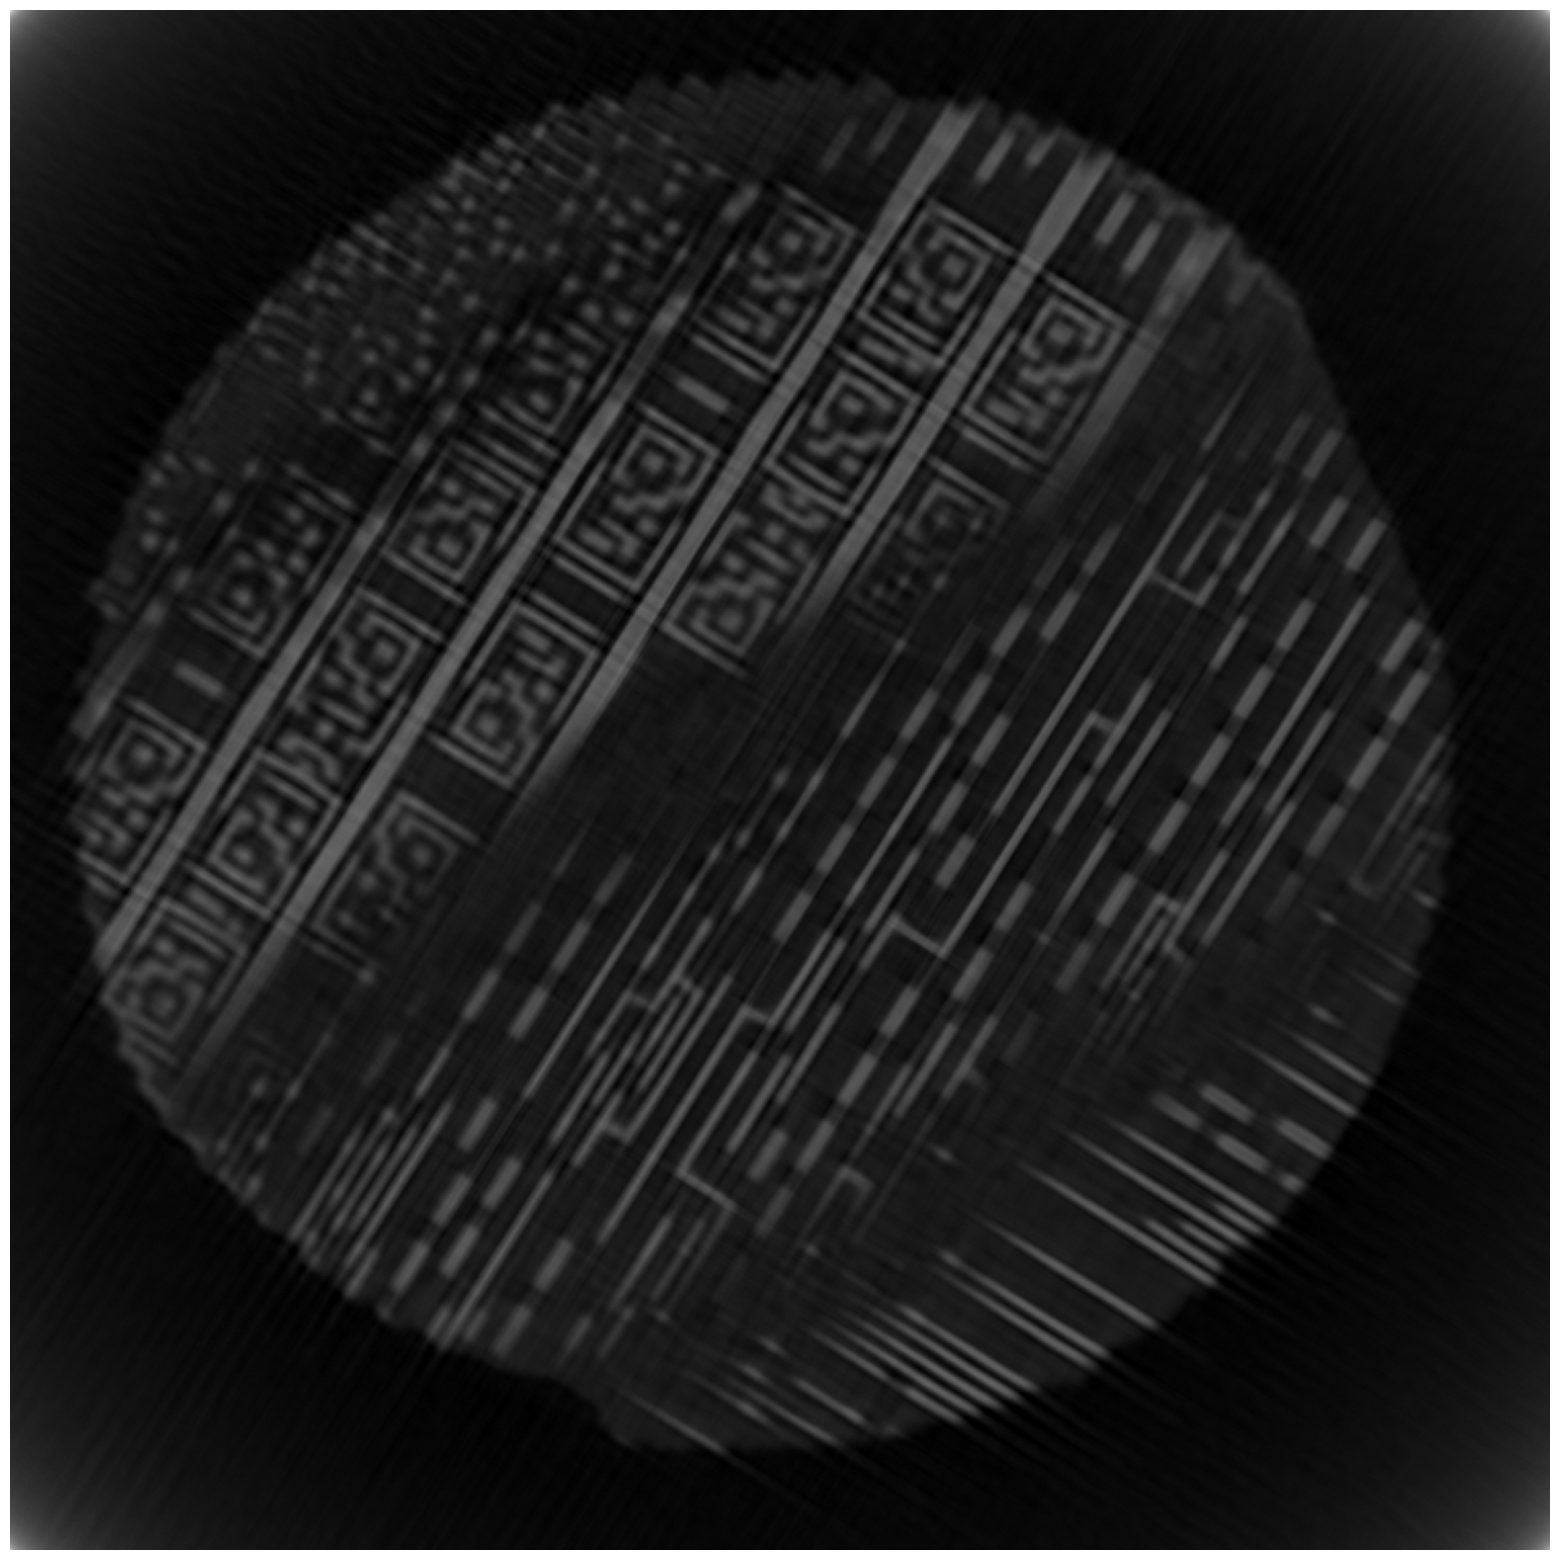

In [15]:
plt.figure(figsize=(20, 20))
plt.imshow(volume_reconstructed[90][200:-200, 200:-200], cmap='gray', vmin=0.0002, vmax=0.002)
plt.axis('off')
plt.show()

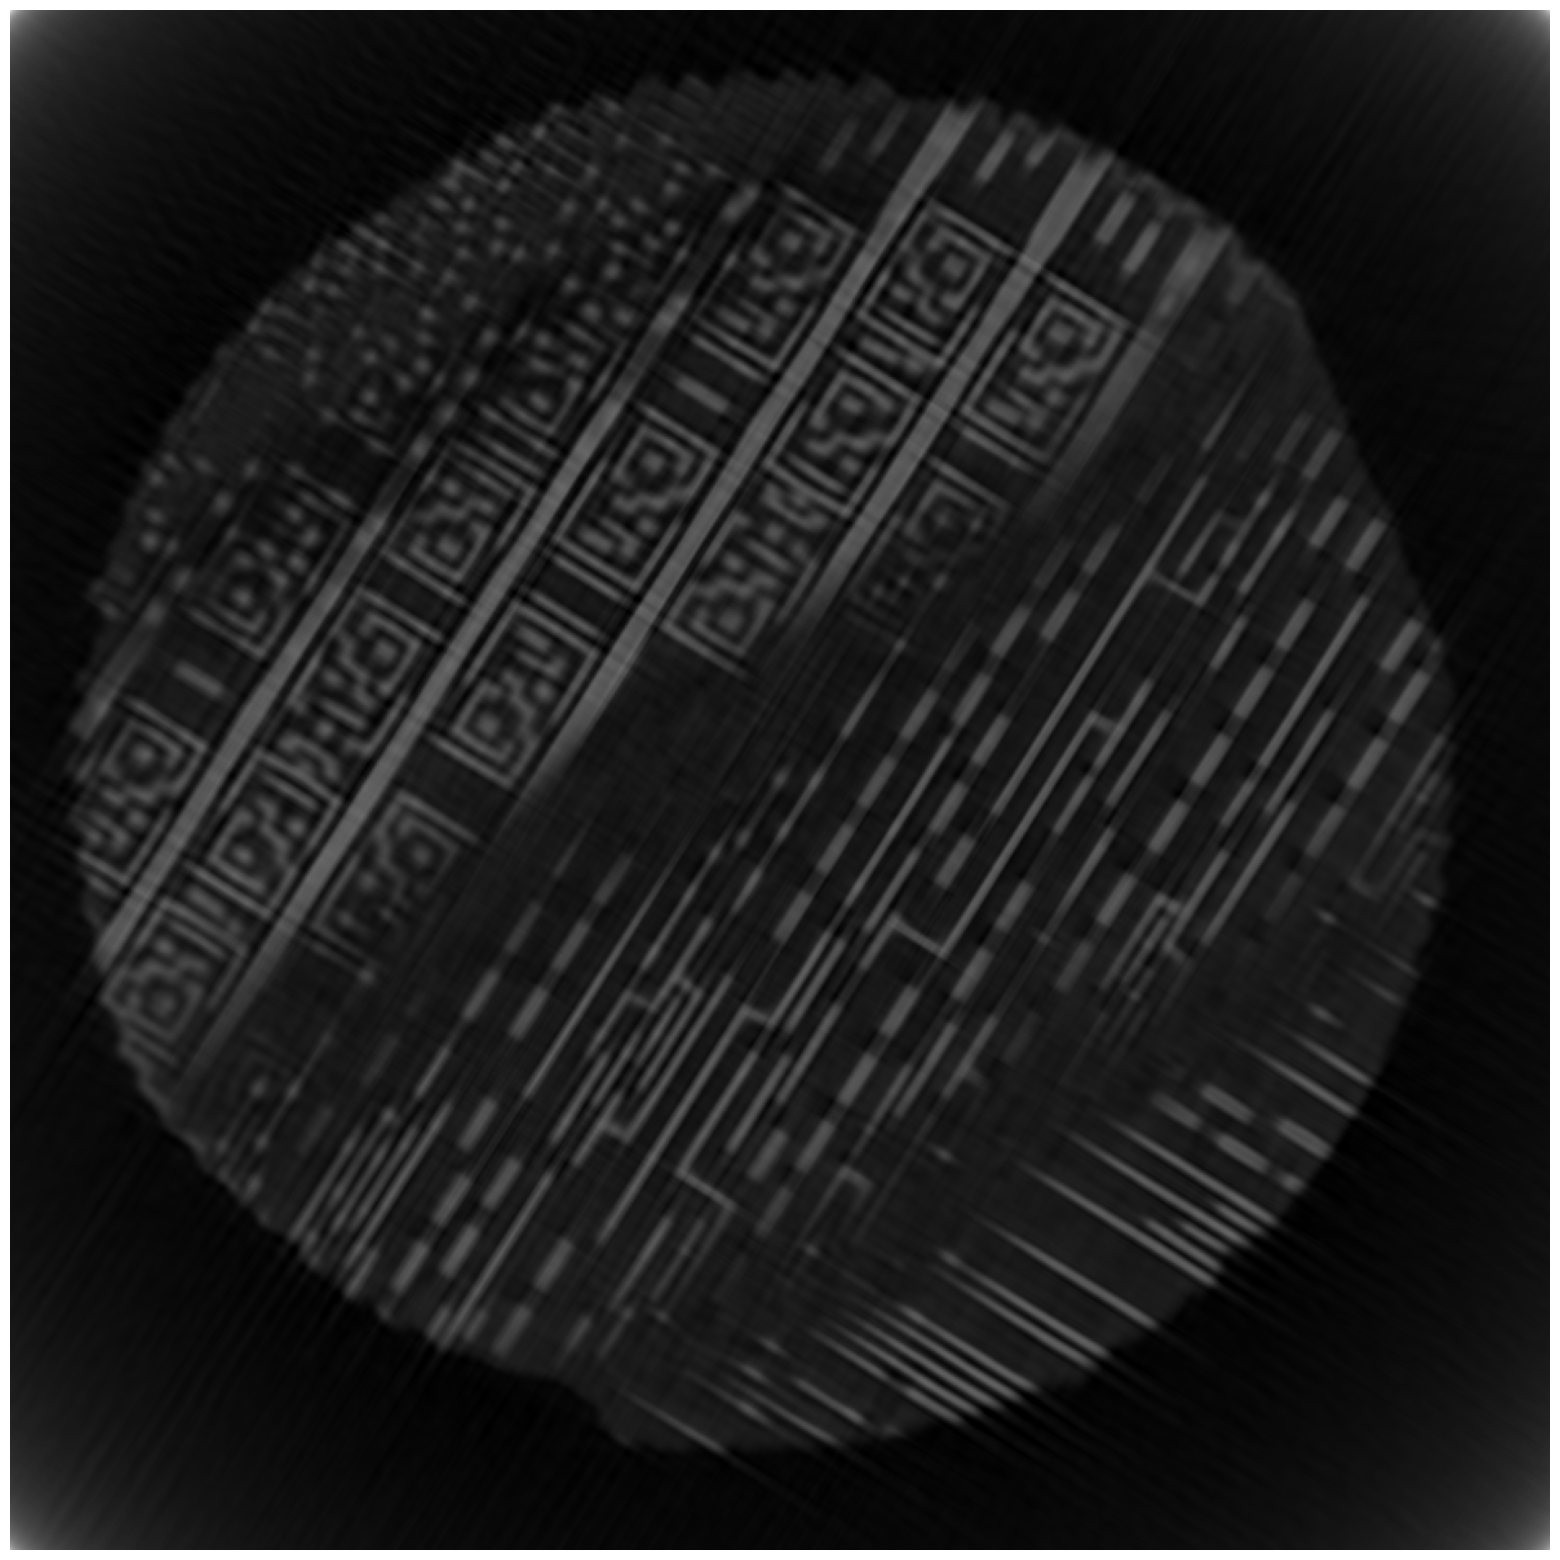

In [16]:
plt.figure(figsize=(20, 20))
plt.imshow(volume_original[90][200:-200, 200:-200], cmap='gray', vmin=0.0002, vmax=0.002)
plt.axis('off')
plt.show()